In [98]:
## Загрузка данных
# Витрины созданы в PostgreSQL (см. sql_queries.sql) и экспортированы в CSV

# Olist - анализ бразильского маркетплейса

Olist - бразильский маркетплейс, связывающий продавцов, покупателей и логистику.

Задача: подготовить аналитику и рекомендации для трех отделов:

- Логистика - оценка сроков доставки, выявление проблемных регионов, влияние задержек на удовлетворенность
- Продажи - анализ динамики выручки, региональной структуры, среднего чека
- Качество - оценка работы продавцов, сегментация, выявление проблемных зон

[Исходные данные (Kaggle)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

Загружено строк: 99222
                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 0

**ВИТРИНА ЛОГИСТИКА**

Подключимся локально к базе данных в PostgreSQL

Смотрим на данные

In [6]:
# Смотрим на данные
df_logistics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_year                   556 non-null    float64
 1   order_month                  556 non-null    float64
 2   customer_state               556 non-null    object 
 3   total_orders                 556 non-null    int64  
 4   delayed_orders               556 non-null    int64  
 5   delay_rate_percent           556 non-null    float64
 6   avg_delay_days               556 non-null    float64
 7   avg_actual_delivery_days     556 non-null    float64
 8   avg_estimated_delivery_days  556 non-null    float64
 9   avg_review_score             556 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 43.6+ KB


In [7]:
# Смотрим первые строки датасета
df_logistics.head(10)

,order_year,order_month,customer_state,total_orders,delayed_orders,delay_rate_percent,avg_delay_days,avg_actual_delivery_days,avg_estimated_delivery_days,avg_review_score
0,2016.0,9.0,SP,1,1,100.0,36.0,54.00,18.00,1.00
1,2016.0,10.0,AL,1,0,0.0,0.0,33.00,66.00,4.00
2,2016.0,10.0,BA,3,0,0.0,0.0,20.33,62.67,4.33
3,2016.0,10.0,CE,6,0,0.0,0.0,26.83,74.17,4.83
4,2016.0,10.0,DF,6,0,0.0,0.0,22.50,57.67,3.17
5,2016.0,10.0,ES,3,0,0.0,0.0,24.67,63.33,4.00
6,2016.0,10.0,GO,7,0,0.0,0.0,13.57,59.43,4.71
7,2016.0,10.0,MA,4,1,25.0,0.0,28.00,64.50,4.67
8,2016.0,10.0,MG,37,0,0.0,0.0,19.14,54.57,3.83
9,2016.0,10.0,MT,1,0,0.0,0.0,7.00,62.00,5.00


Предобработка

In [8]:
# 1. Проверим, есть ли пропуски
print("Пропуски по колонкам:")
print(df_logistics.isnull().sum())

Пропуски по колонкам:
order_year                     0
order_month                    0
customer_state                 0
total_orders                   0
delayed_orders                 0
delay_rate_percent             0
avg_delay_days                 0
avg_actual_delivery_days       0
avg_estimated_delivery_days    0
avg_review_score               0
dtype: int64


In [9]:
# 2. Проверим тип данных — order_year и order_month должны быть целыми
df_logistics['order_year'] = df_logistics['order_year'].astype(int)
df_logistics['order_month'] = df_logistics['order_month'].astype(int)
print(df_logistics.dtypes)

order_year                       int64
order_month                      int64
customer_state                  object
total_orders                     int64
delayed_orders                   int64
delay_rate_percent             float64
avg_delay_days                 float64
avg_actual_delivery_days       float64
avg_estimated_delivery_days    float64
avg_review_score               float64
dtype: object


In [10]:
# 3. Проверим диапазон дат
# Посмотрим, какие месяцы есть по годам
print(df_logistics.groupby('order_year')['order_month'].unique())

order_year
2016                                [9, 10, 12]
2017    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2018                   [1, 2, 3, 4, 5, 6, 7, 8]
Name: order_month, dtype: object


In [11]:
# 4. Проверим, что доля просрочек не превышает 100%
print("Максимальная доля просрочек:", df_logistics['delay_rate_percent'].max())
print("Минимальная доля просрочек:", df_logistics['delay_rate_percent'].min())

Максимальная доля просрочек: 100.0
Минимальная доля просрочек: 0.0


In [12]:
# 5. Проверим, что оценки в разумном диапазоне (1-5)
print("Максимальная оценка:", df_logistics['avg_review_score'].max())
print("Минимальная оценка:", df_logistics['avg_review_score'].min())

Максимальная оценка: 5.0
Минимальная оценка: 1.0


In [13]:
# Проверим, есть ли аномалии (например, просрочка 0%, но средняя оценка очень низкая)
df_logistics[df_logistics['delay_rate_percent'] == 0].sort_values('avg_review_score').head(5)

,order_year,order_month,customer_state,total_orders,delayed_orders,delay_rate_percent,avg_delay_days,avg_actual_delivery_days,avg_estimated_delivery_days,avg_review_score
23,2017,1,AC,2,0,0.0,0.0,20.00,48.00,2.0
156,2017,6,AM,1,0,0.0,0.0,5.00,32.00,2.0
41,2017,1,RO,3,0,0.0,0.0,28.33,45.33,3.0
24,2017,1,AL,2,0,0.0,0.0,15.00,41.50,3.0
362,2018,1,RR,1,0,0.0,0.0,25.00,52.00,3.0


In [14]:
# Уникальные штаты
print("Уникальные штаты:", df_logistics['customer_state'].unique())
print("Количество штатов:", df_logistics['customer_state'].nunique())

Уникальные штаты: ['SP' 'AL' 'BA' 'CE' 'DF' 'ES' 'GO' 'MA' 'MG' 'MT' 'PA' 'PB' 'PE' 'PI'
 'PR' 'RJ' 'RN' 'RR' 'RS' 'SC' 'SE' 'AC' 'MS' 'RO' 'TO' 'AM' 'AP']
Количество штатов: 27


In [15]:
# Посмотрим на регионы с 100% просрочек
df_logistics[df_logistics['delay_rate_percent'] == 100].sort_values(['order_year', 'order_month'])

,order_year,order_month,customer_state,total_orders,delayed_orders,delay_rate_percent,avg_delay_days,avg_actual_delivery_days,avg_estimated_delivery_days,avg_review_score
0,2016,9,SP,1,1,100.0,36.0,54.0,18.0,1.0


In [16]:
# Заказы без просрочек, но с низкой оценкой (<3)
df_logistics[(df_logistics['delay_rate_percent'] == 0) & 
             (df_logistics['avg_review_score'] < 3)].sort_values('avg_review_score')

,order_year,order_month,customer_state,total_orders,delayed_orders,delay_rate_percent,avg_delay_days,avg_actual_delivery_days,avg_estimated_delivery_days,avg_review_score
23,2017,1,AC,2,0,0.0,0.0,20.0,48.0,2.0
156,2017,6,AM,1,0,0.0,0.0,5.0,32.0,2.0


In [17]:
# Создадим колонку с датой (год-месяц) для удобной визуализации
df_logistics['order_date'] = pd.to_datetime(
    df_logistics['order_year'].astype(str) + '-' + 
    df_logistics['order_month'].astype(str) + '-01'
)

# Создадим колонку с сезоном (опционально)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Зима'
    elif month in [3, 4, 5]:
        return 'Весна'
    elif month in [6, 7, 8]:
        return 'Лето'
    else:
        return 'Осень'

df_logistics['season'] = df_logistics['order_month'].apply(get_season)

# Проверим
print(df_logistics[['order_year', 'order_month', 'order_date', 'season']].head())

   order_year  order_month order_date season
0        2016            9 2016-09-01  Осень
1        2016           10 2016-10-01  Осень
2        2016           10 2016-10-01  Осень
3        2016           10 2016-10-01  Осень
4        2016           10 2016-10-01  Осень


In [18]:
# Выберем колонки для нормализации
cols_to_norm = ['delay_rate_percent', 'avg_delay_days', 'avg_actual_delivery_days', 'avg_review_score']

# Нормализация
scaler = MinMaxScaler()
df_logistics[['norm_' + col for col in cols_to_norm]] = scaler.fit_transform(df_logistics[cols_to_norm])

print(df_logistics[['customer_state', 'delay_rate_percent', 'norm_delay_rate_percent']].head())

  customer_state  delay_rate_percent  norm_delay_rate_percent
0             SP               100.0                      1.0
1             AL                 0.0                      0.0
2             BA                 0.0                      0.0
3             CE                 0.0                      0.0
4             DF                 0.0                      0.0


In [19]:
# Проверка дубликатов
print(f"Всего записей: {len(df_logistics)}")
print(f"Дубликатов: {df_logistics.duplicated().sum()}")

# Проверим дубликаты по ключевым колонкам (год, месяц, штат)
print(f"Дубликатов по (год, месяц, штат): {df_logistics.duplicated(subset=['order_year', 'order_month', 'customer_state']).sum()}")

Всего записей: 556
Дубликатов: 0
Дубликатов по (год, месяц, штат): 0


In [20]:
# Посмотрим на все строки с 100% просрочек
high_delay = df_logistics[df_logistics['delay_rate_percent'] == 100]
print("Строки с 100% просрочек:")
print(high_delay[['order_year', 'order_month', 'customer_state', 'total_orders', 'avg_review_score']])

Строки с 100% просрочек:
   order_year  order_month customer_state  total_orders  avg_review_score
0        2016            9             SP             1               1.0


In [21]:
# Заказы без просрочек, но с низкой оценкой (<3)
low_score_no_delay = df_logistics[(df_logistics['delay_rate_percent'] == 0) & 
                                   (df_logistics['avg_review_score'] < 3)]
print("Низкая оценка (<3) без просрочек:")
print(low_score_no_delay[['order_year', 'order_month', 'customer_state', 'total_orders', 'avg_review_score', 'avg_actual_delivery_days']])

Низкая оценка (<3) без просрочек:
     order_year  order_month customer_state  total_orders  avg_review_score  \
23         2017            1             AC             2               2.0   
156        2017            6             AM             1               2.0   

     avg_actual_delivery_days  
23                       20.0  
156                       5.0  


In [22]:
# Добавим колонку-флаг для надежных данных
df_logistics['reliable'] = df_logistics['total_orders'] >= 10

# Проверим, сколько строк с ненадежными данными
print(f"Строк с total_orders < 10: {(df_logistics['total_orders'] < 10).sum()}")

Строк с total_orders < 10: 110


In [23]:
# Приведем типы к правильному виду
df_logistics['order_year'] = df_logistics['order_year'].astype(int)
df_logistics['order_month'] = df_logistics['order_month'].astype(int)
df_logistics['total_orders'] = df_logistics['total_orders'].astype(int)
df_logistics['delayed_orders'] = df_logistics['delayed_orders'].astype(int)

# Проверим итоговые типы
print(df_logistics.dtypes)

order_year                                int64
order_month                               int64
customer_state                           object
total_orders                              int64
delayed_orders                            int64
delay_rate_percent                      float64
avg_delay_days                          float64
avg_actual_delivery_days                float64
avg_estimated_delivery_days             float64
avg_review_score                        float64
order_date                       datetime64[ns]
season                                   object
norm_delay_rate_percent                 float64
norm_avg_delay_days                     float64
norm_avg_actual_delivery_days           float64
norm_avg_review_score                   float64
reliable                                   bool
dtype: object


Что мы теперь знаем о данных
- Дубликатов нет — отлично
- 100% просрочек — только 1 случай (SP, сентябрь 2016, 1 заказ). Это статистический выброс, не влияет на общую картину
- Низкие оценки без просрочек — 2 случая (AC и AM, по 1-2 заказа). Это говорит о том, что недовольство может быть связано не только с доставкой, но и с качеством товара или работой продавца
- 110 строк (20%) имеют total_orders < 10 — эти данные менее надежны для региональных сравнений, но их можно использовать для динамики по месяцам

In [24]:
# Сохраняем обработанный датасет
df_logistics.to_csv('logistics_vitrina_clean.csv', index=False, encoding='utf-8-sig')
print("Данные сохранены в logistics_vitrina_clean.csv")

Данные сохранены в logistics_vitrina_clean.csv


Отдел логистики обеспокоен ростом сроков доставки и недовольством клиентов. Мы проведем анализ, чтобы ответить на вопросы:
- Как меняется доля просрочек по месяцам? чтобы увидеть динамику и определить, есть ли ухудшение ситуации
- В каких регионах проблема наиболее остра? чтобы сфокусировать усилия на проблемных зонах
- Как задержки влияют на оценки клиентов? чтобы оценить масштаб влияния логистики на удовлетворенность
- Какие регионы требуют первоочередного внимания? — чтобы дать приоритетные рекомендации

При анализе долей и средних значений важно учитывать объем выборки. Если заказов мало (например, 1-2), то даже один просроченный заказ дает 50-100% просрочек, что не отражает реальную ситуацию в регионе. Такие "выбросы" искажают общую картину и могут привести к неверным выводам. Поэтому мы исключаем из анализа месяцы и регионы с количеством заказов менее 20 — это стандартная практика в аналитике для обеспечения статистической надежности результатов.

**Динамика доли просрочек по месяцам (с фильтром >= 20 заказов)**

In [25]:
# Подготовка данных для динамики
monthly_trend = df_logistics.groupby('order_date').agg({
    'total_orders': 'sum',
    'delayed_orders': 'sum'
}).reset_index()
monthly_trend['delay_rate'] = 100 * monthly_trend['delayed_orders'] / monthly_trend['total_orders']

# Фильтруем месяцы с количеством заказов >= 20
monthly_trend_filtered = monthly_trend[monthly_trend['total_orders'] >= 20].copy()

print("Отфильтрованные данные (>=20 заказов):")
print(monthly_trend_filtered[['order_date', 'total_orders', 'delayed_orders', 'delay_rate']].to_string(index=False))

Отфильтрованные данные (>=20 заказов):
order_date  total_orders  delayed_orders  delay_rate
2016-10-01           267               3    1.123596
2017-01-01           757              23    3.038309
2017-02-01          1661              53    3.190849
2017-03-01          2561             142    5.544709
2017-04-01          2309             182    7.882200
2017-05-01          3581             128    3.574421
2017-06-01          3166             122    3.853443
2017-07-01          3912             136    3.476483
2017-08-01          4235             141    3.329398
2017-09-01          4176             216    5.172414
2017-10-01          4506             237    5.259654
2017-11-01          7340            1049   14.291553
2017-12-01          5539             464    8.376963
2018-01-01          7109             466    6.555071
2018-02-01          6639            1061   15.981322
2018-03-01          7041            1503   21.346400
2018-04-01          6809             362    5.316493
2018-05

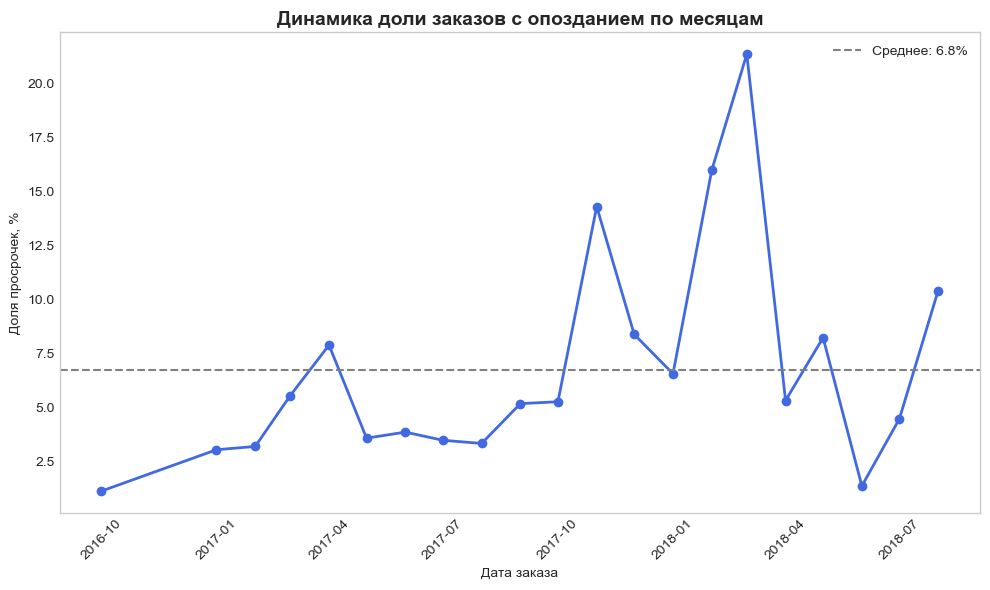

In [26]:
# Визуализация
# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Reds_r")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monthly_trend_filtered['order_date'], monthly_trend_filtered['delay_rate'], 
        marker='o', linewidth=2, markersize=6, color='royalblue')
ax.set_title('Динамика доли заказов с опозданием по месяцам', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Дата заказа')
ax.set_ylabel('Доля просрочек, %')
ax.axhline(y=monthly_trend_filtered['delay_rate'].mean(), color='gray', linestyle='--', 
           label=f'Среднее: {monthly_trend_filtered["delay_rate"].mean():.1f}%')
ax.legend()
ax.grid(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('graph1_delay_dynamics.jpg', dpi=300, bbox_inches='tight')
plt.show()

На графике видно, что доля просрочек нестабильна и имеет ярко выраженные пиковые значения. В ноябре 2017 года просрочки достигли 14,3%, затем снизились, но в феврале-марте 2018 года показатель резко вырос до рекордных 21,3%. После этого наблюдается снижение до минимальных значений в июне 2018 года (1,4%), однако в августе 2018 года доля снова поднялась до 10,4%. Средний уровень просрочек за весь период составляет около 7,5%. Динамика не показывает устойчивого тренда — скорее, наблюдаются волнообразные колебания с опасными всплесками.

**Топ-10 регионов по доле просрочек (с фильтром >= 20 заказов)**

In [27]:
# Агрегируем по регионам (только регионы с >=20 заказами)
region_agg = df_logistics.groupby('customer_state').agg({
    'total_orders': 'sum',
    'delayed_orders': 'sum'
}).reset_index()
region_agg['delay_rate'] = 100 * region_agg['delayed_orders'] / region_agg['total_orders']

# Фильтруем регионы с >=20 заказами
region_agg_filtered = region_agg[region_agg['total_orders'] >= 20].copy()
region_agg_filtered = region_agg_filtered.sort_values('delay_rate', ascending=False).head(10)
region_agg_filtered

,customer_state,total_orders,delayed_orders,delay_rate
1,AL,401,96,23.940150
9,MA,721,141,19.556172
16,PI,477,76,15.932914
5,CE,1282,197,15.366615
24,SE,335,51,15.223881
4,BA,3273,461,14.084937
18,RJ,12420,1674,13.478261
26,TO,274,35,12.773723
13,PA,952,117,12.289916
7,ES,2004,245,12.225549


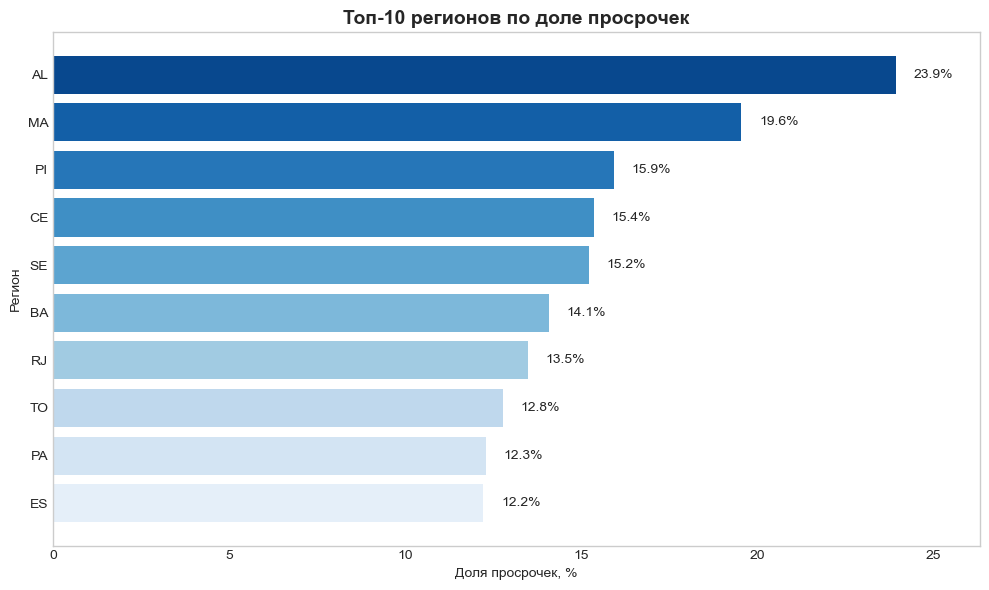

In [28]:
# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Blues_r", len(region_agg_filtered))
bars = ax.barh(region_agg_filtered['customer_state'], region_agg_filtered['delay_rate'], color=colors)
ax.set_title('Топ-10 регионов по доле просрочек', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Доля просрочек, %')
ax.set_ylabel('Регион')
ax.invert_yaxis()

# Добавляем подписи значений
for i, (bar, rate) in enumerate(zip(bars, region_agg_filtered['delay_rate'])):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{rate:.1f}%', va='center', fontsize=10)

# Увеличиваем правую границу графика на 10%
ax.set_xlim(0, region_agg_filtered['delay_rate'].max() * 1.1)

ax.grid(False)
plt.tight_layout()
plt.savefig('graph2_top10_regions.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
print("\nТоп-10 регионов по доле просрочек:")
print(region_agg_filtered[['customer_state', 'total_orders', 'delayed_orders', 'delay_rate']].to_string(index=False))


Топ-10 регионов по доле просрочек:
customer_state  total_orders  delayed_orders  delay_rate
            AL           401              96   23.940150
            MA           721             141   19.556172
            PI           477              76   15.932914
            CE          1282             197   15.366615
            SE           335              51   15.223881
            BA          3273             461   14.084937
            RJ         12420            1674   13.478261
            TO           274              35   12.773723
            PA           952             117   12.289916
            ES          2004             245   12.225549


Лидером антирейтинга является штат AL с долей просрочек почти 24% при 401 заказе. Также в критическую зону попадают MA (19,6%), PI (15,9%), CE (15,4%) и SE (15,2%). Обращает внимание, что штат RJ (Рио-де-Жанейро) с огромным объемом заказов (более 12 тысяч) также имеет высокий уровень просрочек - 13,5%. Это говорит о системной проблеме логистики в крупных и проблемных регионах. Штаты с низким уровнем просрочек (RO, AC, PR, AM, MG) в топ-10 не вошли.

**Связь между задержками и оценками клиентов (с фильтром >=20 заказов)**

In [30]:
# Подготовка данных для корреляции
correlation_data = df_logistics.groupby('customer_state').agg({
    'delay_rate_percent': 'mean',
    'avg_review_score': 'mean',
    'total_orders': 'sum'
}).reset_index()

# Фильтруем регионы с достаточным количеством заказов (>=20)
correlation_data_filtered = correlation_data[correlation_data['total_orders'] >= 20].copy()

# Расчет корреляции
correlation = correlation_data_filtered['delay_rate_percent'].corr(correlation_data_filtered['avg_review_score'])

correlation_data_filtered

,customer_state,delay_rate_percent,avg_review_score,total_orders
0,AC,3.250000,4.059500,80
1,AL,21.068571,3.849524,401
2,AM,3.976842,4.166842,146
3,AP,5.092778,4.342222,67
4,BA,11.955238,3.960952,3273
5,CE,12.864762,4.015238,1282
6,DF,5.782857,4.080952,2099
7,ES,9.748571,4.096667,2004
8,GO,6.419048,4.150952,1974
9,MA,16.697619,3.961429,721


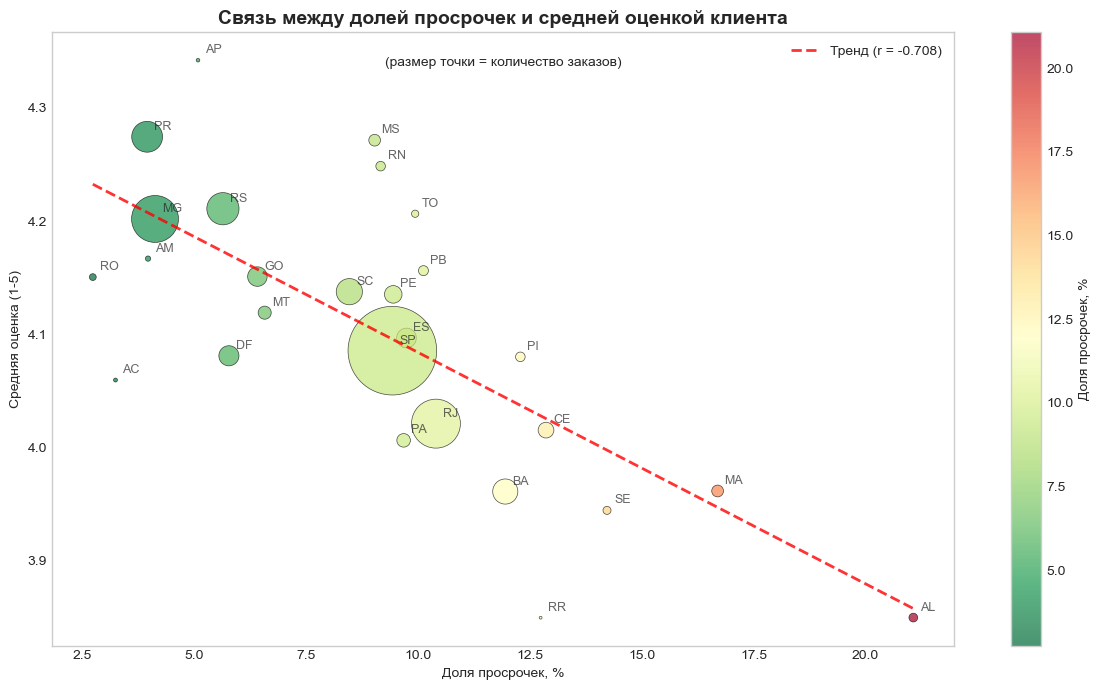


Коэффициент корреляции: -0.708
Интерпретация: чем выше доля просрочек, тем ниже средняя оценка клиента


In [31]:
# Визуализация
fig, ax = plt.subplots(figsize=(12, 7))

# Точечный график
scatter = ax.scatter(correlation_data_filtered['delay_rate_percent'], 
                     correlation_data_filtered['avg_review_score'],
                     s=correlation_data_filtered['total_orders']/10,
                     alpha=0.7, 
                     c=correlation_data_filtered['delay_rate_percent'],
                     cmap='RdYlGn_r',
                     edgecolors='black',
                     linewidth=0.5)

# Добавляем линию тренда
z = np.polyfit(correlation_data_filtered['delay_rate_percent'], correlation_data_filtered['avg_review_score'], 1)
p = np.poly1d(z)
x_trend = np.linspace(correlation_data_filtered['delay_rate_percent'].min(), 
                      correlation_data_filtered['delay_rate_percent'].max(), 100)
ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, 
        label=f'Тренд (r = {correlation:.3f})')

# Добавляем подписи к точкам
for _, row in correlation_data_filtered.iterrows():
    ax.annotate(row['customer_state'], 
                (row['delay_rate_percent'], row['avg_review_score']),
                fontsize=9, alpha=0.7, 
                xytext=(5, 5), textcoords='offset points')

ax.set_title('Связь между долей просрочек и средней оценкой клиента', fontsize=14, fontweight='bold')
ax.text(0.5, 0.96, '(размер точки = количество заказов)', 
        transform=ax.transAxes, fontsize=10, ha='center', va='top')
ax.set_xlabel('Доля просрочек, %')
ax.set_ylabel('Средняя оценка (1-5)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Добавляем цветовую шкалу
cbar = plt.colorbar(scatter, label='Доля просрочек, %')
ax.grid(False)
plt.tight_layout()
plt.savefig('graph3_correlation.jpg', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nКоэффициент корреляции: {correlation:.3f}")
print("Интерпретация: чем выше доля просрочек, тем ниже средняя оценка клиента")

Коэффициент корреляции составил -0,708, что указывает на сильную обратную связь между долей просрочек и средней оценкой клиента. Это означает: чем чаще заказы доставляются с опозданием, тем ниже клиенты ставят оценки. Линия тренда наглядно показывает эту закономерность. Например, штат AL с максимальной долей просрочек (21,1%) имеет одну из самых низких оценок (3,85). В то же время штаты с низким уровнем просрочек (RO, PR, MG) демонстрируют оценки выше 4,2. Это подтверждает, что логистика является ключевым фактором удовлетворенности клиентов.

**Региональная карта проблем**

In [32]:
# Подготовка данных для карты регионов
region_summary = df_logistics.groupby('customer_state').agg({
    'delay_rate_percent': 'mean',
    'total_orders': 'sum',
    'avg_review_score': 'mean'
}).reset_index()

# Фильтруем регионы с >=20 заказами
region_summary_filtered = region_summary[region_summary['total_orders'] >= 20].copy()
region_summary_filtered = region_summary_filtered.sort_values('delay_rate_percent', ascending=True)

# Категории просрочек
def get_delay_category(rate):
    if rate < 5:
        return 'Низкая (<5%)'
    elif rate < 10:
        return 'Средняя (5-10%)'
    elif rate < 20:
        return 'Высокая (10-20%)'
    else:
        return 'Критическая (>20%)'

region_summary_filtered['delay_category'] = region_summary_filtered['delay_rate_percent'].apply(get_delay_category)
region_summary_filtered

,customer_state,delay_rate_percent,total_orders,avg_review_score,delay_category
20,RO,2.743500,243,4.150500,Низкая (<5%)
0,AC,3.250000,80,4.059500,Низкая (<5%)
17,PR,3.956818,4942,4.274545,Низкая (<5%)
2,AM,3.976842,146,4.166842,Низкая (<5%)
10,MG,4.132857,11423,4.201905,Низкая (<5%)
3,AP,5.092778,67,4.342222,Средняя (5-10%)
22,RS,5.649048,5381,4.210952,Средняя (5-10%)
6,DF,5.782857,2099,4.080952,Средняя (5-10%)
8,GO,6.419048,1974,4.150952,Средняя (5-10%)
12,MT,6.581905,889,4.119048,Средняя (5-10%)


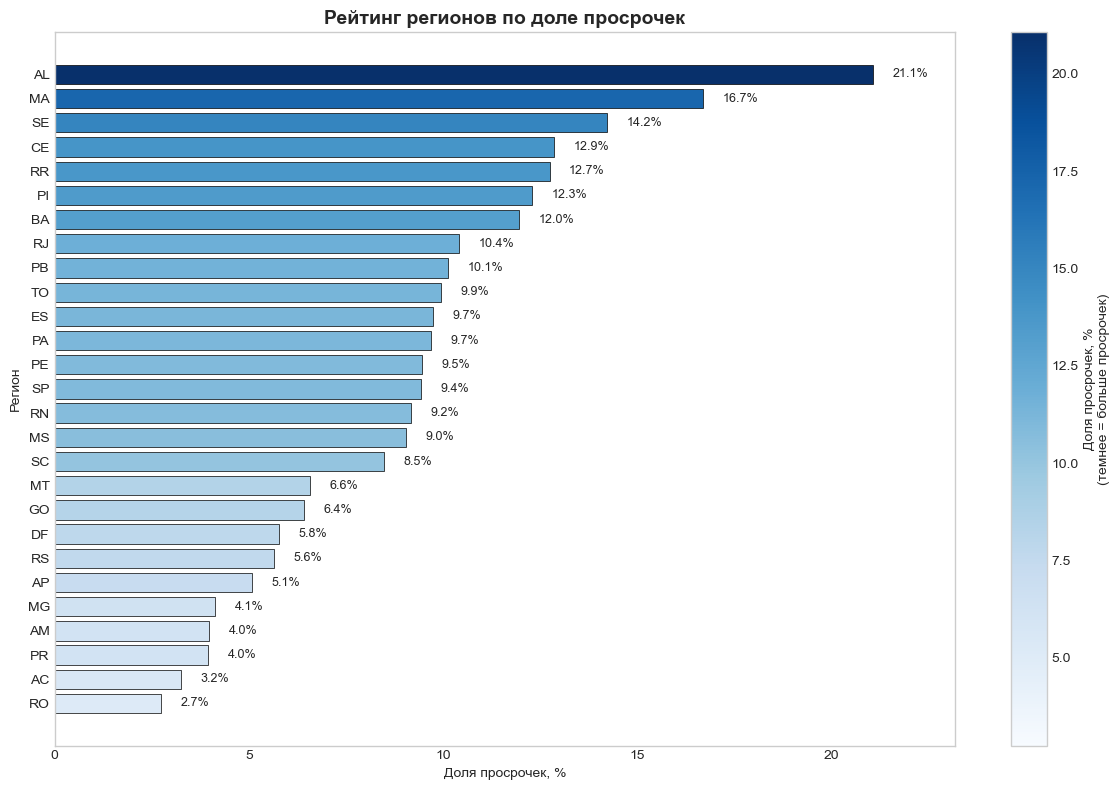

In [33]:
# Визуализация в синих оттенках (от темного к светлому)
fig, ax = plt.subplots(figsize=(12, 8))

# Сортируем данные по доле просрочек для лучшей визуализации
region_summary_filtered_sorted = region_summary_filtered.sort_values('delay_rate_percent', ascending=True)

# Создаем цветовую шкалу: от темно-синего (высокие значения) к светло-синему (низкие значения)
# Используем обычный Blues (без _r), тогда высокие значения будут темнее
colors = plt.cm.Blues(region_summary_filtered_sorted['delay_rate_percent'] / 
                       region_summary_filtered_sorted['delay_rate_percent'].max())

bars = ax.barh(region_summary_filtered_sorted['customer_state'], 
               region_summary_filtered_sorted['delay_rate_percent'], 
               color=colors,
               edgecolor='black',
               linewidth=0.5)

ax.set_title('Рейтинг регионов по доле просрочек', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Доля просрочек, %')
ax.set_ylabel('Регион')

# Добавляем подписи значений
for bar, rate in zip(bars, region_summary_filtered_sorted['delay_rate_percent']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{rate:.1f}%', va='center', fontsize=9)

# Добавляем цветовую шкалу (от темного к светлому)
sm = plt.cm.ScalarMappable(cmap='Blues', 
                           norm=plt.Normalize(vmin=region_summary_filtered_sorted['delay_rate_percent'].min(), 
                                            vmax=region_summary_filtered_sorted['delay_rate_percent'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Доля просрочек, %\n(темнее = больше просрочек)', fontsize=10)

# Увеличиваем правую границу графика на 10%
ax.set_xlim(0, region_summary_filtered_sorted['delay_rate_percent'].max() * 1.1)

ax.grid(False)
plt.tight_layout()
plt.savefig('graph4_region_map.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
print("\nРегионы по категориям просрочек:")
for category in ['Критическая (>20%)', 'Высокая (10-20%)', 'Средняя (5-10%)', 'Низкая (<5%)']:
    regions = region_summary_filtered[region_summary_filtered['delay_category'] == category]['customer_state'].tolist()
    if regions:
        print(f"{category}: {', '.join(regions)}")


Регионы по категориям просрочек:
Критическая (>20%): AL
Высокая (10-20%): PB, RJ, BA, PI, RR, CE, SE, MA
Средняя (5-10%): AP, RS, DF, GO, MT, SC, MS, RN, SP, PE, PA, ES, TO
Низкая (<5%): RO, AC, PR, AM, MG


Регионы четко разделились на четыре категории. В критическую зону (просрочки более 20%) попал только штат AL. В зону высокого риска (10-20%) вошли 8 штатов: PB, RJ, BA, PI, RR, CE, SE, MA. Особое беспокойство вызывает штат RJ - при огромном объеме заказов (12420) он имеет высокий уровень просрочек. В среднюю зону (5-10%) попали 13 штатов, включая SP с крупнейшим объемом заказов (40705). В благополучную зону (менее 5%) вошли 5 штатов: RO, AC, PR, AM, MG.

**Динамика просрочек по проблемным регионам, топ -3**

In [35]:
# Выделим топ-3 проблемных регионов
top_problem_regions = region_agg_filtered.head(3)['customer_state'].tolist()
print(f"Анализируемые регионы: {top_problem_regions}")

# Подготовка данных по месяцам для этих регионов
monthly_region_data = df_logistics[df_logistics['customer_state'].isin(top_problem_regions)].copy()
monthly_region_data = monthly_region_data[monthly_region_data['total_orders'] >= 20]  # фильтр по месяцам

# Выводим столбцы с долей просрочки и месяцемзаказа
print("\nДанные по месяцам для топ-3 проблемных регионов:")
print(monthly_region_data[['customer_state', 'order_month', 'delay_rate_percent']].to_string(index=False))

Анализируемые регионы: ['AL', 'MA', 'PI']

Данные по месяцам для топ-3 проблемных регионов:
customer_state  order_month  delay_rate_percent
            MA            3               22.73
            AL            4               45.45
            MA            4                3.85
            AL            5                7.41
            MA            5                0.00
            PI            5                0.00
            MA            7                2.70
            PI            7                5.00
            MA            8                5.13
            PI            8                5.00
            MA            9                9.76
            PI            9                4.55
            AL           10               10.34
            MA           10               27.08
            PI           10                4.17
            AL           11               23.08
            MA           11               52.73
            PI           11               58

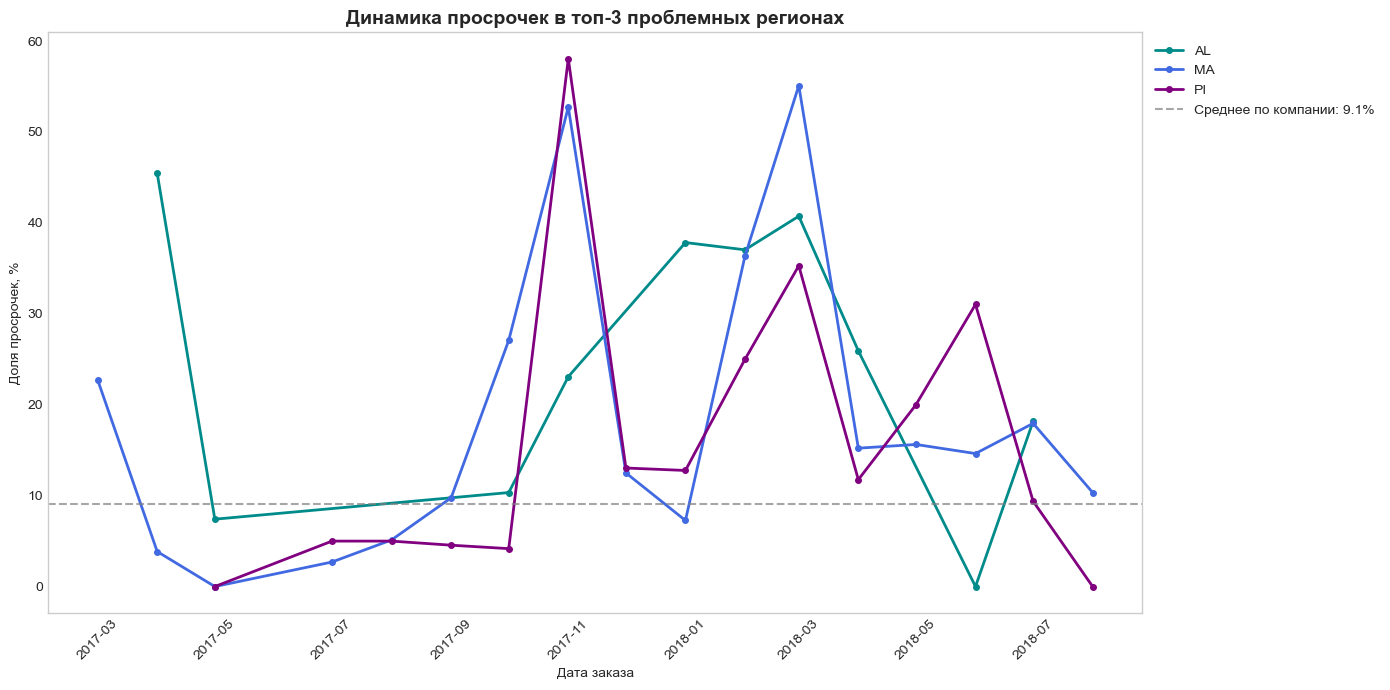

In [36]:
# Визуализация
fig, ax = plt.subplots(figsize=(14, 7))

# Определяем цвета для регионов
colors = ['darkcyan', 'royalblue', 'purple']  # Фиолетовый - 'purple' или можно 'mediumpurple', 'darkviolet'

for i, region in enumerate(top_problem_regions):
    region_data = monthly_region_data[monthly_region_data['customer_state'] == region]
    ax.plot(region_data['order_date'], region_data['delay_rate_percent'], 
            marker='o', linewidth=2, markersize=4, label=region, color=colors[i % len(colors)])

ax.set_title('Динамика просрочек в топ-3 проблемных регионах', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Дата заказа')
ax.set_ylabel('Доля просрочек, %')
ax.axhline(y=df_logistics['delay_rate_percent'].mean(), color='gray', linestyle='--', 
           alpha=0.7, label=f'Среднее по компании: {df_logistics["delay_rate_percent"].mean():.1f}%')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
ax.grid(False)
plt.tight_layout()
plt.savefig('graph5_top3_regions_dynamics.jpg', dpi=300, bbox_inches='tight')
plt.show()

График показывает, что проблема просрочек в регионах AL, MA и PI носит не постоянный, а волнообразный характер. В MA наблюдаются экстремальные всплески: в ноябре 2017 года просрочки достигли 52,7%, а в марте 2018 года 55,1%. В AL пиковые значения также высоки: 45,5% в апреле 2017 года, 40,7% в марте 2018 года. Однако в отдельные месяцы показатели снижаются до 0% (AL в июне 2018, MA в мае 2017, PI в августе 2018). Это говорит о том, что проблема не в отсутствии логистических мощностей как таковых, а в нестабильности процессов - возможно, связанной с сезонностью, загрузкой партнеров или локальными кризисами.

**ВИТИРНА ПРОДАЖ**

Загружаем витрину продаж локально из csv

In [38]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_year            556 non-null    float64
 1   order_month           556 non-null    float64
 2   customer_state        556 non-null    object 
 3   total_orders          556 non-null    int64  
 4   total_revenue         556 non-null    float64
 5   avg_order_value       556 non-null    float64
 6   unique_customers      556 non-null    int64  
 7   revenue_per_customer  556 non-null    float64
dtypes: float64(5), int64(2), object(1)
memory usage: 34.9+ KB


In [39]:
df_sales.head(10)

,order_year,order_month,customer_state,total_orders,total_revenue,avg_order_value,unique_customers,revenue_per_customer
0,2016.0,9.0,SP,1,143.46,143.460000,1,143.460000
1,2016.0,10.0,AL,1,76.60,76.600000,1,76.600000
2,2016.0,10.0,BA,3,321.01,107.003333,3,107.003333
3,2016.0,10.0,CE,6,1885.38,314.230000,6,314.230000
4,2016.0,10.0,DF,6,1200.11,200.018333,6,200.018333
5,2016.0,10.0,ES,3,991.81,330.603333,3,330.603333
6,2016.0,10.0,GO,7,1056.12,150.874286,7,150.874286
7,2016.0,10.0,MA,4,998.85,249.712500,4,249.712500
8,2016.0,10.0,MG,35,4937.40,141.068571,35,141.068571
9,2016.0,10.0,MT,1,101.44,101.440000,1,101.440000


In [41]:
# 1. Проверка дубликатов
print(f"Всего записей: {len(df_sales)}")
print(f"Дубликатов (полные): {df_sales.duplicated().sum()}")
print(f"Дубликатов по (год, месяц, штат): {df_sales.duplicated(subset=['order_year', 'order_month', 'customer_state']).sum()}")

Всего записей: 556
Дубликатов (полные): 0
Дубликатов по (год, месяц, штат): 0


In [42]:
# 2. Проверка пропусков
print(df_sales.isnull().sum())

order_year              0
order_month             0
customer_state          0
total_orders            0
total_revenue           0
avg_order_value         0
unique_customers        0
revenue_per_customer    0
dtype: int64


In [43]:
# 3. Приведение типов данных
# order_year и order_month должны быть целыми
df_sales['order_year'] = df_sales['order_year'].astype(int)
df_sales['order_month'] = df_sales['order_month'].astype(int)

# Создаем дату для удобства
df_sales['order_date'] = pd.to_datetime(
    df_sales['order_year'].astype(str) + '-' + 
    df_sales['order_month'].astype(str) + '-01'
)

# Проверяем типы
print(df_sales.dtypes)

order_year                       int64
order_month                      int64
customer_state                  object
total_orders                     int64
total_revenue                  float64
avg_order_value                float64
unique_customers                 int64
revenue_per_customer           float64
order_date              datetime64[ns]
dtype: object


In [44]:
# 4. Проверка уникальных значений в категориальной колонке
print(f"Уникальных штатов: {df_sales['customer_state'].nunique()}")
print(f"Список штатов: {sorted(df_sales['customer_state'].unique())}")

Уникальных штатов: 27
Список штатов: ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


In [45]:
# 5. Проверка на нелогичные значения
# Проверка: выручка не может быть отрицательной
print(f"Записи с отрицательной выручкой: {(df_sales['total_revenue'] < 0).sum()}")

# Проверка: количество заказов не может быть отрицательным
print(f"Записи с отрицательным количеством заказов: {(df_sales['total_orders'] < 0).sum()}")

# Проверка: средний чек не может быть отрицательным
print(f"Записи с отрицательным средним чеком: {(df_sales['avg_order_value'] < 0).sum()}")

Записи с отрицательной выручкой: 0
Записи с отрицательным количеством заказов: 0
Записи с отрицательным средним чеком: 0


In [46]:
# 6. Статистика по числовым колонкам
print(df_sales[['total_orders', 'total_revenue', 'avg_order_value', 'unique_customers', 'revenue_per_customer']].describe())

       total_orders  total_revenue  avg_order_value  unique_customers  \
count    556.000000     556.000000       556.000000        556.000000   
mean     173.521583   27733.406025       196.876452        173.521583   
std      431.227619   62334.355616        78.255731        431.227619   
min        1.000000      19.620000        19.620000          1.000000   
25%       13.000000    2658.320000       152.739752         13.000000   
50%       37.000000    7878.155000       175.990728         37.000000   
75%      133.500000   22121.995000       220.013523        133.500000   
max     3164.000000  478501.730000       750.710000       3164.000000   

       revenue_per_customer  
count            556.000000  
mean             196.876452  
std               78.255731  
min               19.620000  
25%              152.739752  
50%              175.990728  
75%              220.013523  
max              750.710000  


In [47]:
# 7. Проверка аномалий: выручка есть, а заказов нет (или наоборот)
# Выручка есть, но заказов 0
print(f"Выручка > 0, но заказов = 0: {((df_sales['total_revenue'] > 0) & (df_sales['total_orders'] == 0)).sum()}")

# Заказы есть, но выручка 0
print(f"Заказы > 0, но выручка = 0: {((df_sales['total_orders'] > 0) & (df_sales['total_revenue'] == 0)).sum()}")

# Средний чек сильно отличается от выручки/заказы
df_sales['calculated_avg'] = df_sales['total_revenue'] / df_sales['total_orders']
mismatch = abs(df_sales['avg_order_value'] - df_sales['calculated_avg']) > 0.01
print(f"Расхождения в среднем чеке (более 0.01): {mismatch.sum()}")
if mismatch.sum() > 0:
    print(df_sales[mismatch][['customer_state', 'order_year', 'order_month', 'avg_order_value', 'calculated_avg']].head())

Выручка > 0, но заказов = 0: 0
Заказы > 0, но выручка = 0: 0
Расхождения в среднем чеке (более 0.01): 0


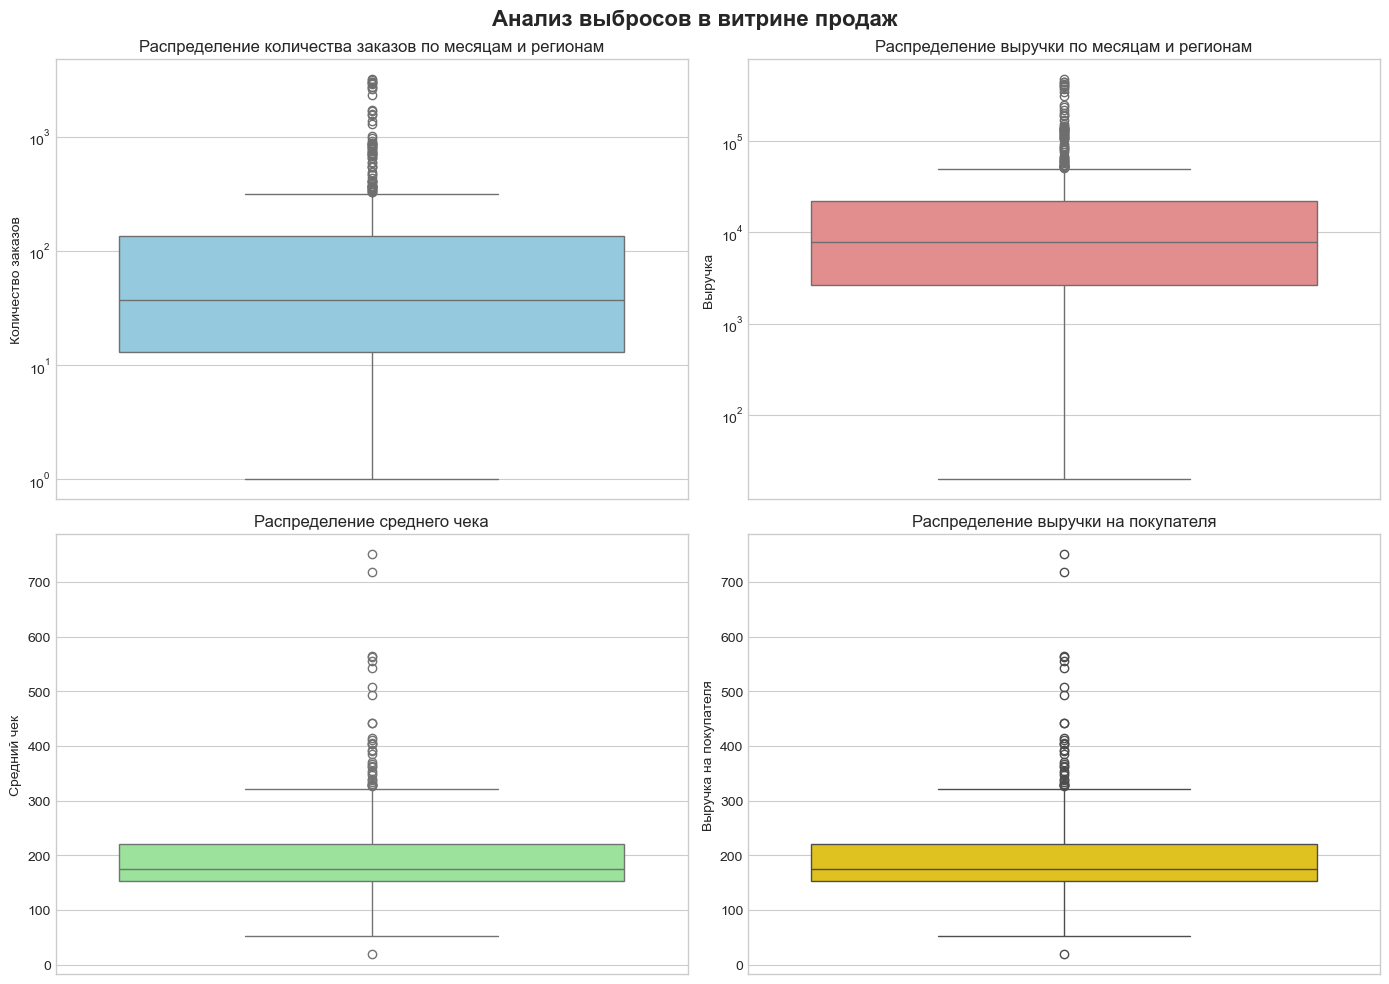

In [48]:
# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Создаем фигуру с несколькими подграфиками
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ выбросов в витрине продаж', fontsize=16, fontweight='bold')

# 1. Распределение количества заказов
sns.boxplot(y=df_sales['total_orders'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Распределение количества заказов по месяцам и регионам')
axes[0, 0].set_ylabel('Количество заказов')
axes[0, 0].set_yscale('log')  # логарифмическая шкала для лучшего отображения

# 2. Распределение выручки
sns.boxplot(y=df_sales['total_revenue'], ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Распределение выручки по месяцам и регионам')
axes[0, 1].set_ylabel('Выручка')
axes[0, 1].set_yscale('log')

# 3. Распределение среднего чека
sns.boxplot(y=df_sales['avg_order_value'], ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Распределение среднего чека')
axes[1, 0].set_ylabel('Средний чек')

# 4. Распределение выручки на покупателя
sns.boxplot(y=df_sales['revenue_per_customer'], ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Распределение выручки на покупателя')
axes[1, 1].set_ylabel('Выручка на покупателя')
ax.grid(False)
plt.tight_layout()
plt.show()

In [49]:
print("ТОП-20 ЗАПИСЕЙ ПО ВЫРУЧКЕ")
top_revenue = df_sales.nlargest(20, 'total_revenue')[['customer_state', 'order_year', 'order_month', 'total_orders', 'total_revenue', 'avg_order_value']]
print(top_revenue.to_string(index=False))

ТОП-20 ЗАПИСЕЙ ПО ВЫРУЧКЕ
customer_state  order_year  order_month  total_orders  total_revenue  avg_order_value
            SP        2018            5          3138      478501.73       152.486211
            SP        2018            8          3164      443835.20       140.276612
            SP        2018            4          3002      443425.34       147.709973
            SP        2018            3          2971      429111.51       144.433359
            SP        2018            1          2975      418292.49       140.602518
            SP        2017           11          2899      401000.87       138.323860
            SP        2018            6          2738      392059.69       143.191998
            SP        2018            7          2715      371820.82       136.950578
            SP        2018            2          2632      350950.36       133.339802
            SP        2017           12          2295      313102.51       136.428109
            SP        2017  

In [50]:
print("ТОП-20 ЗАПИСЕЙ ПО СРЕДНЕМУ ЧЕКУ")
top_avg = df_sales.nlargest(20, 'avg_order_value')[['customer_state', 'order_year', 'order_month', 'total_orders', 'total_revenue', 'avg_order_value']]
print(top_avg.to_string(index=False))

ТОП-20 ЗАПИСЕЙ ПО СРЕДНЕМУ ЧЕКУ
customer_state  order_year  order_month  total_orders  total_revenue  avg_order_value
            AC        2018            5             2        1501.42       750.710000
            MS        2017            2            11        7910.94       719.176364
            AP        2017           10             3        1696.74       565.580000
            AL        2017            8            17        9558.32       562.254118
            TO        2017            6             8        4441.12       555.140000
            AP        2018            2             2        1086.31       543.155000
            PB        2018            6            28       14221.13       507.897500
            DF        2017            2            21       10366.60       493.647619
            AC        2018            7             4        1769.95       442.487500
            PA        2017            2            24       10604.70       441.862500
            RO        

In [51]:
# Проверим, не связано ли это с малым количеством заказов
high_avg = df_sales[df_sales['avg_order_value'] > 500].copy()
high_avg['order_month_year'] = high_avg['order_year'].astype(str) + '-' + high_avg['order_month'].astype(str)

print("АНАЛИЗ ЗАПИСЕЙ С ВЫСОКИМ СРЕДНИМ ЧЕКОМ (>500)")

for _, row in high_avg.iterrows():
    print(f"{row['customer_state']} | {int(row['order_year'])}-{int(row['order_month'])} | заказов: {row['total_orders']} | средний чек: {row['avg_order_value']:.0f}")

АНАЛИЗ ЗАПИСЕЙ С ВЫСОКИМ СРЕДНИМ ЧЕКОМ (>500)
MS | 2017-2 | заказов: 11 | средний чек: 719
TO | 2017-6 | заказов: 8 | средний чек: 555
AL | 2017-8 | заказов: 17 | средний чек: 562
AP | 2017-10 | заказов: 3 | средний чек: 566
AP | 2018-2 | заказов: 2 | средний чек: 543
AC | 2018-5 | заказов: 2 | средний чек: 751
PB | 2018-6 | заказов: 28 | средний чек: 508


In [52]:
# Проверим, сколько из них с малым количеством заказов (<10)
high_avg_small = high_avg[high_avg['total_orders'] < 10]
print(f"\nИз них с total_orders < 10: {len(high_avg_small)}")
print(high_avg_small[['customer_state', 'order_year', 'order_month', 'total_orders', 'avg_order_value']])


Из них с total_orders < 10: 4
    customer_state  order_year  order_month  total_orders  avg_order_value
180             TO        2017            6             8          555.140
264             AP        2017           10             3          565.580
371             AP        2018            2             2          543.155
449             AC        2018            5             2          750.710


In [53]:
# Создаем фильтрованные данные (аналогично логистике: >=20 заказов)
df_sales_filtered = df_sales[df_sales['total_orders'] >= 20].copy()
print("СРАВНЕНИЕ ДО И ПОСЛЕ ФИЛЬТРАЦИИ (>=20 ЗАКАЗОВ)")
print(f"Исходных записей: {len(df_sales)}")
print(f"После фильтрации: {len(df_sales_filtered)}")
print(f"Удалено записей: {len(df_sales) - len(df_sales_filtered)} ({(1 - len(df_sales_filtered)/len(df_sales))*100:.1f}%)")

СРАВНЕНИЕ ДО И ПОСЛЕ ФИЛЬТРАЦИИ (>=20 ЗАКАЗОВ)
Исходных записей: 556
После фильтрации: 371
Удалено записей: 185 (33.3%)


Фильтр >=20 заказов для продаж не нужен, потому что бизнес-логика другая. В логистике мы фильтровали, чтобы не искажать долю просрочек малыми выборками. Для продаж малые регионы с 2-3 заказами и высоким чеком - это реальная бизнес-информация (например, кто-то купил дорогой товар в отдаленном регионе). Потеряем важные инсайты - 33% данных потеряем, а вместе с ними уникальную информацию о дорогих покупках в малых регионах.

Выбросы в продажах - это не ошибка, а особенности бизнеса. Мы их не удаляем, а учитываем при анализе.

In [54]:
# Сохраняем очищенную витрину
df_sales.to_csv('sales_vitrina_clean.csv', index=False, encoding='utf-8-sig')
print("Данные сохранены в sales_vitrina_clean.csv")
print(f"Всего записей: {len(df_sales)}")
print(f"Уникальных регионов: {df_sales['customer_state'].nunique()}")
print(f"Диапазон дат: {df_sales['order_year'].min()}-{df_sales['order_year'].max()}")

Данные сохранены в sales_vitrina_clean.csv
Всего записей: 556
Уникальных регионов: 27
Диапазон дат: 2016-2018


**Динамика выручки и количества заказов по месяцам**

Выручка и количество заказов - базовые метрики, показывающие общее состояние бизнеса. Два графика на одной оси позволяют увидеть, растет ли бизнес за счет увеличения числа заказов или роста среднего чека. Линейный график выбран для отслеживания тренда во времени.

In [55]:
# Подготовка данных
monthly_sales = df_sales.groupby('order_date').agg({
    'total_orders': 'sum',
    'total_revenue': 'sum'
}).reset_index()
print("Данные для графика:")
print(monthly_sales.to_string(index=False))

Данные для графика:
order_date  total_orders  total_revenue
2016-09-01             1         143.46
2016-10-01           265       46490.66
2016-12-01             1          19.62
2017-01-01           750      127482.37
2017-02-01          1653      271239.32
2017-03-01          2546      414330.95
2017-04-01          2303      390812.40
2017-05-01          3546      566851.40
2017-06-01          3135      490050.37
2017-07-01          3872      566299.08
2017-08-01          4193      645832.36
2017-09-01          4150      701077.49
2017-10-01          4478      751117.01
2017-11-01          7289     1153364.20
2017-12-01          5513      843078.29
2018-01-01          7069     1077887.46
2018-02-01          6555      966168.41
2018-03-01          7003     1120598.24
2018-04-01          6798     1132878.93
2018-05-01          6749     1128774.52
2018-06-01          6099     1011978.29
2018-07-01          6159     1027807.28
2018-08-01          6351      985491.64


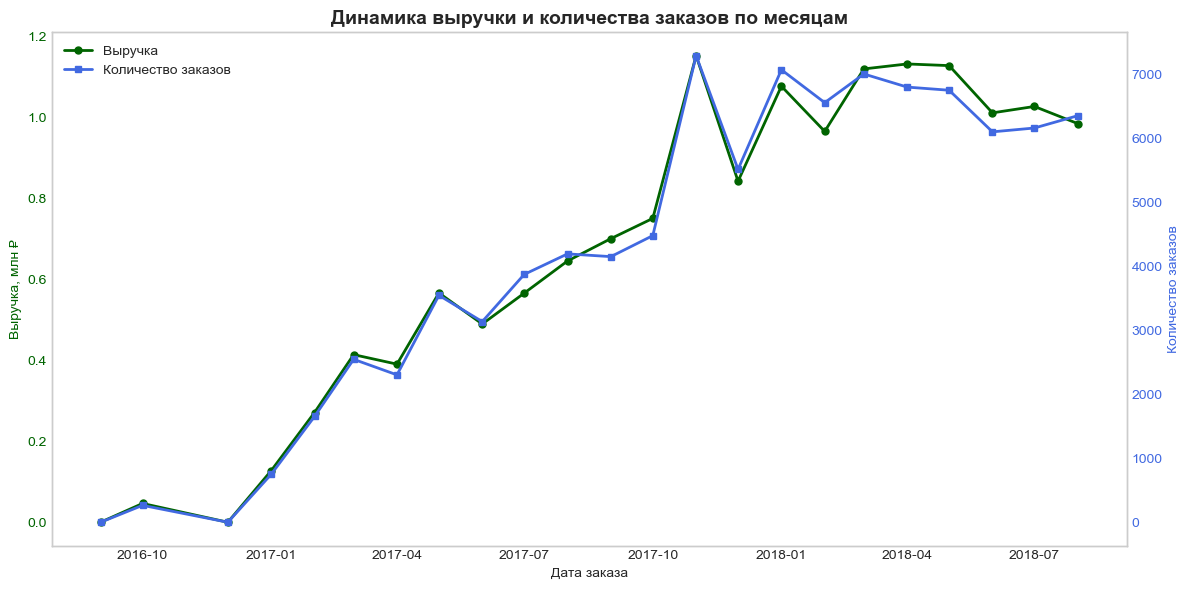

In [56]:
# Визуализация
fig, ax1 = plt.subplots(figsize=(12, 6))

# График выручки (левая ось)
ax1.plot(monthly_sales['order_date'], monthly_sales['total_revenue'], 
         marker='o', linewidth=2, markersize=5, color='darkgreen', label='Выручка')
ax1.set_xlabel('Дата заказа')
ax1.set_ylabel('Выручка, млн ₽', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')

# Форматируем ось Y в миллионах
import matplotlib.ticker as ticker
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))

# График количества заказов (правая ось)
ax2 = ax1.twinx()
ax2.plot(monthly_sales['order_date'], monthly_sales['total_orders'], 
         marker='s', linewidth=2, markersize=5, color='royalblue', label='Количество заказов')
ax2.set_ylabel('Количество заказов', color='royalblue')
ax2.tick_params(axis='y', labelcolor='royalblue')

# Заголовок и легенда
plt.title('Динамика выручки и количества заказов по месяцам', fontsize=14, fontweight='bold')

# Объединяем легенды
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Отключаем сетку для ОБЕИХ осей
ax1.grid(False)
ax2.grid(False)

# Также отключаем сетку на основном figure
plt.grid(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('graph_sales1_dynamics.jpg', dpi=300, bbox_inches='tight')
plt.savefig('sales_graph1_dynamics.jpg', dpi=300, bbox_inches='tight')
plt.show()

**Топ-10 регионов по выручке**

Региональный срез выручки показывает, где бизнес зарабатывает основные деньги. Горизонтальная гистограмма выбрана для удобства чтения названий штатов. 

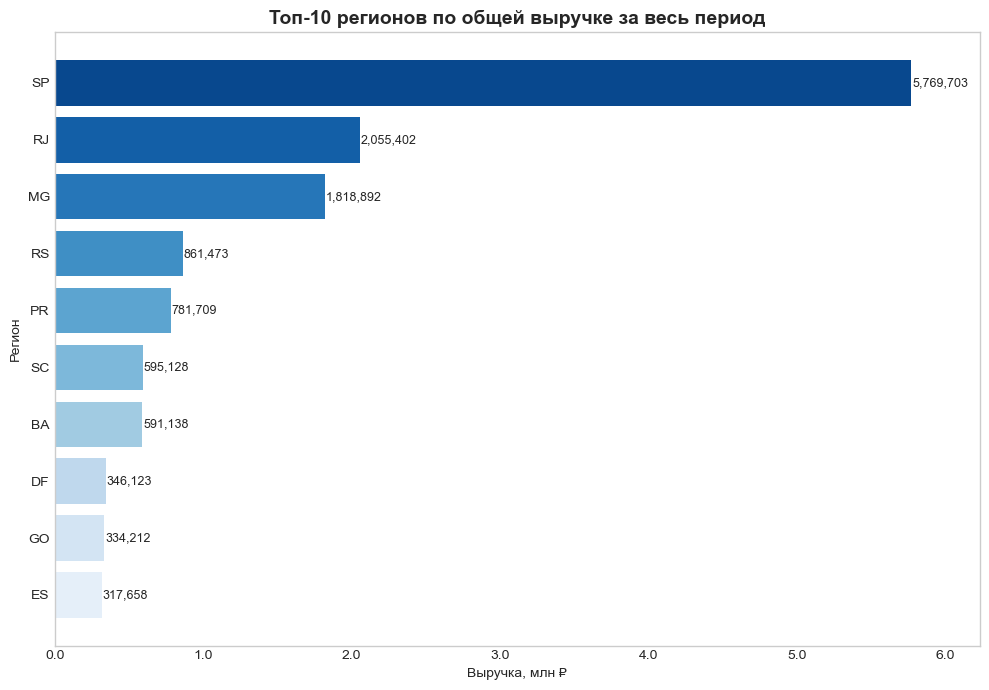

In [57]:
# Агрегация по регионам
region_sales = df_sales.groupby('customer_state').agg({
    'total_orders': 'sum',
    'total_revenue': 'sum',
    'unique_customers': 'sum'
}).reset_index()
region_sales = region_sales.sort_values('total_revenue', ascending=False).head(10)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Blues_r", len(region_sales))
bars = ax.barh(region_sales['customer_state'], region_sales['total_revenue'], color=colors)
ax.set_title('Топ-10 регионов по общей выручке за весь период', fontsize=14, fontweight='bold')
ax.set_xlabel('Выручка, млн ₽')  # Добавляем "млн" в подпись оси
ax.set_ylabel('Регион')
ax.invert_yaxis()

# Форматируем ось X в миллионах
import matplotlib.ticker as ticker
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))

# Добавляем подписи значений (оставляем в исходном формате)
for bar, revenue in zip(bars, region_sales['total_revenue']):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, 
            f'{revenue:,.0f}', va='center', fontsize=9)

# Увеличиваем правую границу графика на 10%
ax.set_xlim(0, region_sales['total_revenue'].max() * 1.08)

ax.grid(False)
plt.tight_layout()
plt.savefig('graph_sales2_top10_revenue.jpg', dpi=300, bbox_inches='tight')
plt.savefig('sales_graph2_top10_revenue.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [58]:
print("Топ-10 регионов по выручке:")
print(region_sales[['customer_state', 'total_orders', 'total_revenue', 'unique_customers']].to_string(index=False))

Топ-10 регионов по выручке:
customer_state  total_orders  total_revenue  unique_customers
            SP         40501     5769703.15             40501
            RJ         12350     2055401.57             12350
            MG         11354     1818891.67             11354
            RS          5345      861472.79              5345
            PR          4923      781708.80              4923
            SC          3546      595127.78              3546
            BA          3256      591137.81              3256
            DF          2080      346123.35              2080
            GO          1957      334212.35              1957
            ES          1995      317657.93              1995


**Средний чек по регионам**

Средний чек показывает покупательскую способность региона и ценовое позиционирование. Горизонтальная гистограмма позволяет сравнить регионы.

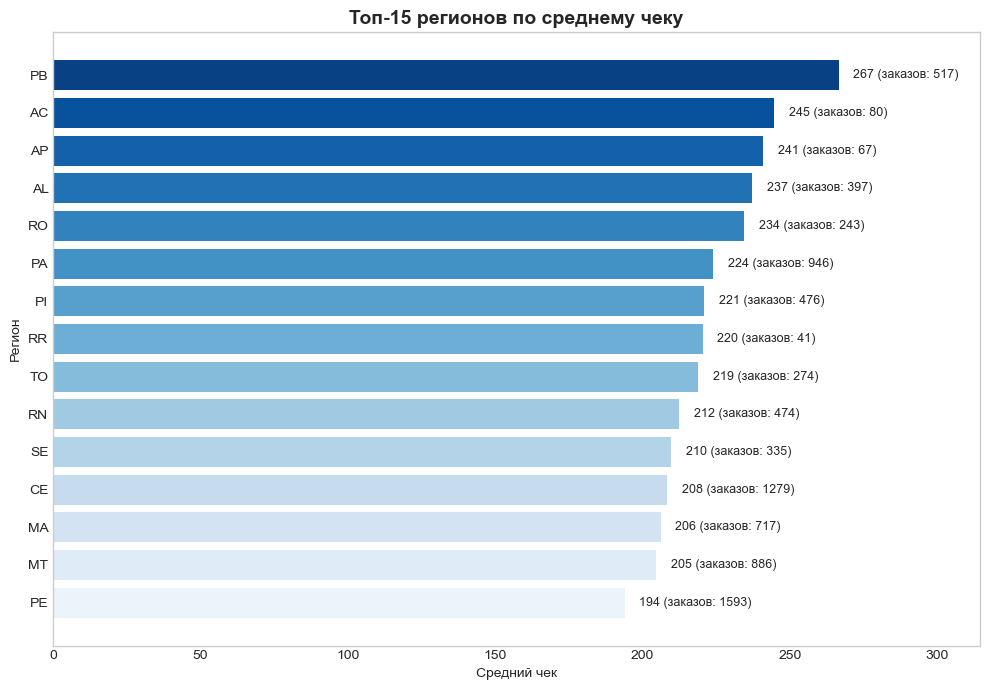

In [59]:
# Агрегация по регионам (средний чек как средневзвешенный)
region_avg = df_sales.groupby('customer_state').agg({
    'total_orders': 'sum',
    'total_revenue': 'sum'
}).reset_index()
region_avg['avg_order_value'] = region_avg['total_revenue'] / region_avg['total_orders']
region_avg = region_avg.sort_values('avg_order_value', ascending=False).head(15)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Blues_r", len(region_avg))
bars = ax.barh(region_avg['customer_state'], region_avg['avg_order_value'], color=colors)
ax.set_title('Топ-15 регионов по среднему чеку', fontsize=14, fontweight='bold')
ax.set_xlabel('Средний чек')
ax.set_ylabel('Регион')
ax.invert_yaxis()

# Добавляем подписи значений
for bar, value, orders in zip(bars, region_avg['avg_order_value'], region_avg['total_orders']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{value:.0f} (заказов: {orders})', va='center', fontsize=9)

# Увеличиваем правую границу графика на 15%
ax.set_xlim(0, region_avg['avg_order_value'].max() * 1.18)

ax.grid(False)
plt.tight_layout()
plt.savefig('graph_sales3_avg_check.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [60]:
print("Топ-15 регионов по среднему чеку (с указанием количества заказов):")
print(region_avg[['customer_state', 'total_orders', 'avg_order_value']].to_string(index=False))

Топ-15 регионов по среднему чеку (с указанием количества заказов):
customer_state  total_orders  avg_order_value
            PB           517       266.612282
            AC            80       244.691625
            AP            67       240.922537
            AL           397       237.210302
            RO           243       234.427984
            PA           946       224.126395
            PI           476       220.962584
            RR            41       220.476098
            TO           274       219.005000
            RN           474       212.478439
            SE           335       209.818299
            CE          1279       208.316474
            MA           717       206.141632
            MT           886       204.542235
            PE          1593       193.956089


In [61]:
# Агрегация по регионам (средний чек как средневзвешенный) для ВСЕХ регионов
region_avg_all = df_sales.groupby('customer_state').agg({
    'total_orders': 'sum',
    'total_revenue': 'sum'
}).reset_index()
region_avg_all['avg_order_value'] = region_avg_all['total_revenue'] / region_avg_all['total_orders']

# Сортируем по выручке по убыванию
region_avg_all = region_avg_all.sort_values('total_revenue', ascending=False)

# Выводим в формате pandas
print("\nСРЕДНИЙ ЧЕК ПО ВСЕМ РЕГИОНАМ (от большего к меньшему по выручке):")
print(region_avg_all[['customer_state', 'total_orders', 'total_revenue', 'avg_order_value']].to_string(index=False))

# Сохраняем в Excel только таблицу
output_file = 'region_avg_check.xlsx'

# Подготавливаем DataFrame для сохранения с русскими названиями столбцов
df_to_save = region_avg_all[['customer_state', 'total_orders', 'total_revenue', 'avg_order_value']].copy()
df_to_save.columns = ['Регион', 'Количество заказов', 'Общая выручка', 'Средний чек']

# Сохраняем в Excel
df_to_save.to_excel(output_file, index=False, sheet_name='Средний чек по регионам')

print(f"\nТаблица сохранена в файл: {output_file}")
print(f"Лист: Средний чек по регионам (отсортировано по выручке от большего к меньшему)")


СРЕДНИЙ ЧЕК ПО ВСЕМ РЕГИОНАМ (от большего к меньшему по выручке):
customer_state  total_orders  total_revenue  avg_order_value
            SP         40501     5769703.15       142.458289
            RJ         12350     2055401.57       166.429277
            MG         11354     1818891.67       160.198315
            RS          5345      861472.79       161.173581
            PR          4923      781708.80       158.787081
            SC          3546      595127.78       167.830733
            BA          3256      591137.81       181.553381
            DF          2080      346123.35       166.405457
            GO          1957      334212.35       170.777900
            ES          1995      317657.93       159.227033
            PE          1593      308972.05       193.956089
            CE          1279      266436.77       208.316474
            PA           946      212023.57       224.126395
            MT           886      181224.42       204.542235
            MA    

In [62]:
# Статистика по всем регионам
print(f"\nСтатистика по всем регионам:")
print(f"  Средний чек (мин): {region_avg_all['avg_order_value'].min():.0f}")
print(f"  Средний чек (макс): {region_avg_all['avg_order_value'].max():.0f}")
print(f"  Средний чек (средний): {region_avg_all['avg_order_value'].mean():.0f}")
print(f"  Медианный чек: {region_avg_all['avg_order_value'].median():.0f}")


Статистика по всем регионам:
  Средний чек (мин): 142
  Средний чек (макс): 267
  Средний чек (средний): 199
  Медианный чек: 205


**Темп роста выручки по регионам (январь-август 2017 → 2018)**

Отделу продаж важно понимать, какие регионы показывают рост, а какие теряют динамику. Для корректного сравнения выбран период январь-август - единственный сопоставимый отрезок для 2017 и 2018 годов (оба года имеют данные за эти 8 месяцев). Сравнение полных лет невозможно из-за отсутствия данных за сентябрь-декабрь 2018 года, а включение неполного 2016 года исказило бы результаты.

Горизонтальная гистограмма с цветовой кодировкой позволяет быстро оценить ситуацию по всем 27 регионам. Синий цвет обозначает рост (чем темнее, тем выше темп), красный - падение (чем темнее, тем глубже падение). Вертикальная линия x=0 разделяет зоны роста и падения.

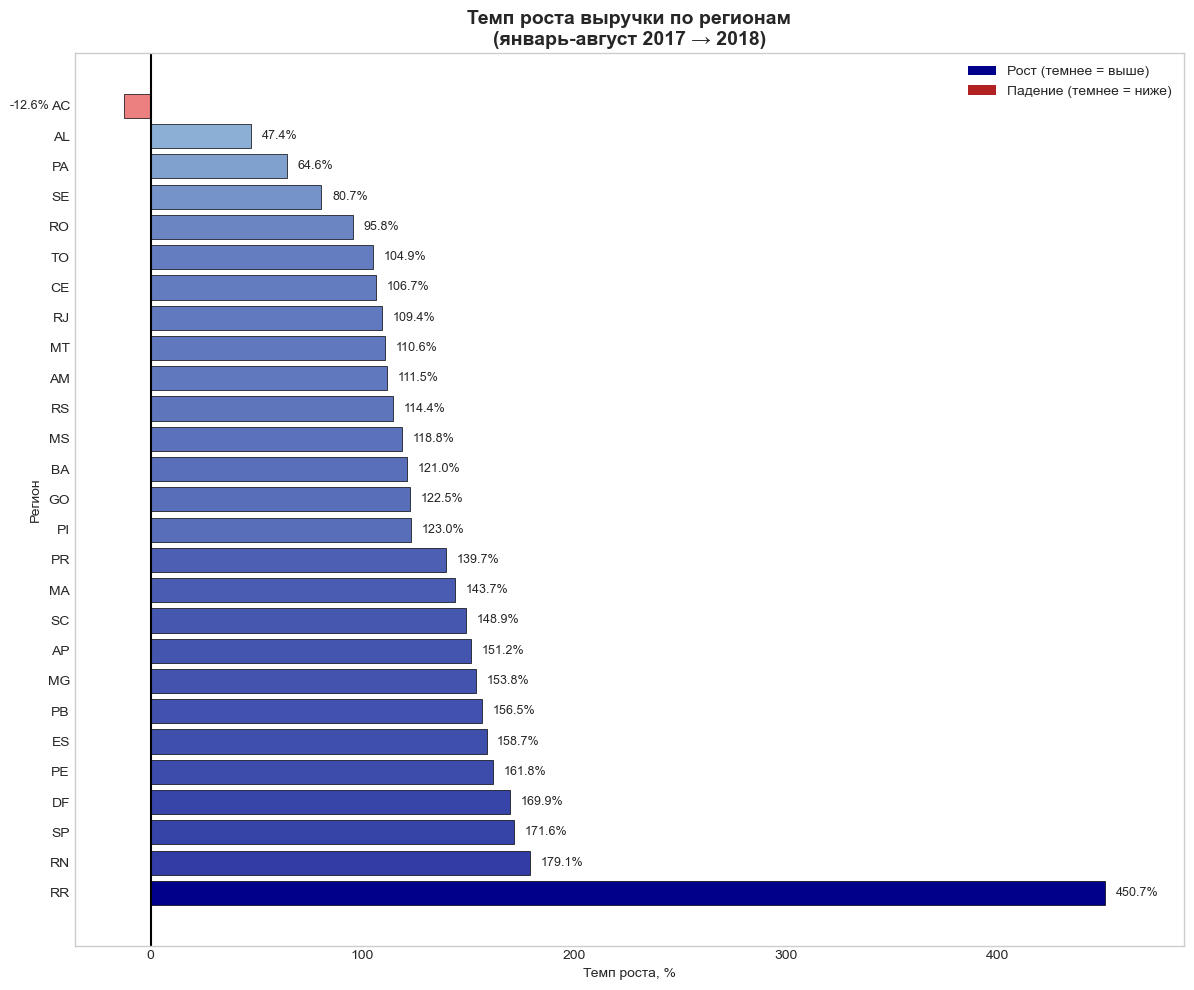

In [63]:
# Подготовка данных: выручка по регионам за 2017 и 2018 (январь-август)
revenue_2017_full = df_sales[(df_sales['order_year'] == 2017) & (df_sales['order_month'] <= 8)].groupby('customer_state')['total_revenue'].sum().reset_index()
revenue_2017_full.columns = ['customer_state', 'revenue_2017']

revenue_2018_full = df_sales[(df_sales['order_year'] == 2018) & (df_sales['order_month'] <= 8)].groupby('customer_state')['total_revenue'].sum().reset_index()
revenue_2018_full.columns = ['customer_state', 'revenue_2018']

# Объединяем и считаем темп роста
growth_data = pd.merge(revenue_2017_full, revenue_2018_full, on='customer_state', how='inner')
growth_data['growth_rate'] = ((growth_data['revenue_2018'] - growth_data['revenue_2017']) / growth_data['revenue_2017'] * 100).round(1)

# Сортируем по темпу роста
growth_data = growth_data.sort_values('growth_rate', ascending=False)

# Создаем градиентную окраску (синий для роста, красный для падения)
def get_color(rate):
    if rate >= 0:
        # Синяя гамма: от светло-синего до темно-синего
        norm = min(rate / 250, 1)
        r, g, b = 0, 0, 139        # Темно-синий (darkblue)
        light_r, light_g, light_b = 173, 216, 230  # Светло-синий (lightblue)
        r_final = light_r + norm * (r - light_r)
        g_final = light_g + norm * (g - light_g)
        b_final = light_b + norm * (b - light_b)
        return (r_final/255, g_final/255, b_final/255)
    else:
        # Красная гамма: от светло-красного до темно-красного
        norm = min(abs(rate) / 50, 1)
        r, g, b = 178, 34, 34       # Темно-красный (firebrick)
        light_r, light_g, light_b = 255, 160, 160  # Светло-красный
        r_final = light_r + norm * (r - light_r)
        g_final = light_g + norm * (g - light_g)
        b_final = light_b + norm * (b - light_b)
        return (r_final/255, g_final/255, b_final/255)

colors = [get_color(rate) for rate in growth_data['growth_rate']]

# Визуализация
fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(growth_data['customer_state'], growth_data['growth_rate'], 
                color=colors, edgecolor='black', linewidth=0.5)

ax.set_title('Темп роста выручки по регионам\n(январь-август 2017 → 2018)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Темп роста, %')
ax.set_ylabel('Регион')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)

# Добавляем подписи значений
for bar, rate in zip(bars, growth_data['growth_rate']):
    offset = 5 if rate >= 0 else -35
    ha = 'left' if rate >= 0 else 'right'
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2, 
            f'{rate:.1f}%', va='center', ha=ha, fontsize=9)

# Легенда - переносим наверх справа
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#00008B', label='Рост (темнее = выше)'),
                   Patch(facecolor='#B22222', label='Падение (темнее = ниже)')]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))


ax.grid(False)
current_xlim = ax.get_xlim()
ax.set_xlim(current_xlim[0], current_xlim[1] * 1.03)

plt.tight_layout()
plt.savefig('sales_graph4_growth_heatmap.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [64]:
print("РЕГИОНЫ С МАКСИМАЛЬНЫМ РОСТОМ (топ-5):")
print(growth_data.head(5)[['customer_state', 'revenue_2017', 'revenue_2018', 'growth_rate']].to_string(index=False))
print("РЕГИОНЫ С МАКСИМАЛЬНЫМ ПАДЕНИЕМ (топ-5):")
print(growth_data.tail(5)[['customer_state', 'revenue_2017', 'revenue_2018', 'growth_rate']].to_string(index=False))

РЕГИОНЫ С МАКСИМАЛЬНЫМ РОСТОМ (топ-5):
customer_state  revenue_2017  revenue_2018  growth_rate
            RR       1264.60       6963.92        450.7
            RN      20214.12      56408.91        179.1
            SP    1225231.48    3327997.14        171.6
            DF      71601.54     193264.59        169.9
            PE      63123.61     165285.81        161.8
РЕГИОНЫ С МАКСИМАЛЬНЫМ ПАДЕНИЕМ (топ-5):
customer_state  revenue_2017  revenue_2018  growth_rate
            RO      13614.07      26654.13         95.8
            SE      18029.33      32583.79         80.7
            PA      63309.70     104222.30         64.6
            AL      29314.94      43223.36         47.4
            AC       7644.46       6683.10        -12.6


**Вклад регионов в общую выручку**

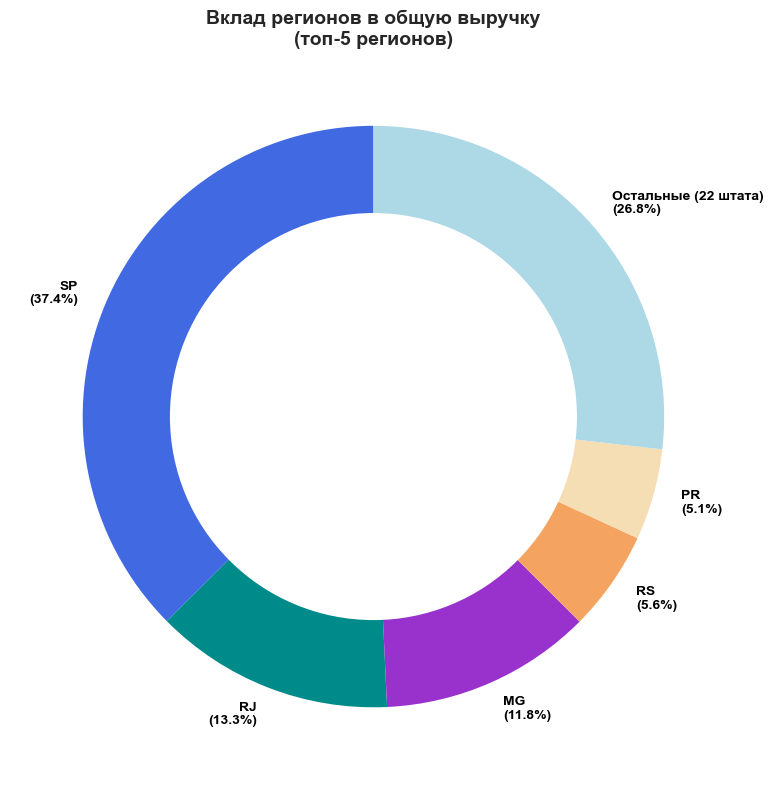

In [65]:
# Подготовка данных
region_share = df_sales.groupby('customer_state')['total_revenue'].sum().reset_index()
region_share = region_share.sort_values('total_revenue', ascending=False)
region_share['share'] = 100 * region_share['total_revenue'] / region_share['total_revenue'].sum()

# Выделяем топ-5, остальные объединяем в "Остальные"
top5 = region_share.head(5).copy()
others = pd.DataFrame({
    'customer_state': ['Остальные (22 штата)'],
    'total_revenue': [region_share.iloc[5:]['total_revenue'].sum()],
    'share': [region_share.iloc[5:]['share'].sum()]
})
pie_data = pd.concat([top5, others])

# Создаем подписи в формате "SP (37.4%)"
labels = [f"{row['customer_state']}\n({row['share']:.1f}%)" 
          for _, row in pie_data.iterrows()]

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))

# Новые цвета
colors_pie = ['royalblue', 'darkcyan', 'darkorchid', 'sandybrown', 'wheat', 'lightblue']

# pie() возвращает 2 значения, когда autopct=None
wedges, texts = ax.pie(pie_data['total_revenue'], 
                        labels=labels,
                        autopct=None,  # Отключаем автоподписи процентов
                        colors=colors_pie,
                        startangle=90)

# Настраиваем подписи (названия штатов с процентами)
for text in texts:
    text.set_color('black')
    text.set_fontweight('bold')
    text.set_fontsize(10)

# Добавляем кольцо внутри
centre_circle = plt.Circle((0, 0), 0.70, fc='white', linewidth=1.25)
ax.add_artist(centre_circle)

ax.set_title('Вклад регионов в общую выручку\n(топ-5 регионов)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graph_sales5_pie_share.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [66]:
print("Доля топ-5 регионов в общей выручке:")
for _, row in top5.iterrows():
    print(f"  {row['customer_state']}: {row['share']:.1f}%")
print(f"  Всего топ-5: {top5['share'].sum():.1f}%")

Доля топ-5 регионов в общей выручке:
  SP: 37.4%
  RJ: 13.3%
  MG: 11.8%
  RS: 5.6%
  PR: 5.1%
  Всего топ-5: 73.2%


**ВИТРИНА КАЧЕСТВО**

Загружаем витрину качества локально из csv

In [68]:
df_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2965 entries, 0 to 2964
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   seller_id              2965 non-null   object 
 1   seller_state           2965 non-null   object 
 2   total_orders           2965 non-null   int64  
 3   avg_review_score       2965 non-null   float64
 4   negative_reviews       2965 non-null   int64  
 5   positive_reviews       2965 non-null   int64  
 6   negative_rate_percent  2965 non-null   float64
 7   positive_rate_percent  2965 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 185.4+ KB


In [69]:
df_quality.head(10)

,seller_id,seller_state,total_orders,avg_review_score,negative_reviews,positive_reviews,negative_rate_percent,positive_rate_percent
0,154bdf805377afea75a3bd158e9eab10,SP,1,1.0,1,0,100.0,0.0
1,c004e5ea15737026cecaee0447e00b75,SP,1,1.0,1,0,100.0,0.0
2,8d92f3ea807b89465643c219455e7369,SP,8,1.0,8,0,100.0,0.0
3,8e670472e453ba34a379331513d6aab1,MG,1,1.0,1,0,100.0,0.0
4,cb4a705d00e100b9732d0ca34817d441,SC,2,1.0,2,0,100.0,0.0
5,749e7cdabbaf72f16677859e27874ba5,SP,1,1.0,1,0,100.0,0.0
6,c97aa4ee7420f937da13b7f9e2228b99,RS,1,1.0,1,0,100.0,0.0
7,ab75b89cc49c9ab3160d0c91565a442a,SP,1,1.0,1,0,100.0,0.0
8,6d04126aba80df143fd038e711b8fd96,RJ,1,1.0,1,0,100.0,0.0
9,1f7dfad2cb384ea4d2d7e1ffbd78c407,SP,1,1.0,1,0,100.0,0.0


In [99]:
print(f"Всего продавцов: {len(df_quality)}")
print(f"Диапазон оценок: {df_quality['avg_review_score'].min()} - {df_quality['avg_review_score'].max()}")

Всего продавцов: 2965
Диапазон оценок: 1.0 - 5.0


In [71]:
# 1. Проверка пропусков (уже видим, что нет)
print(df_quality.isnull().sum())

seller_id                0
seller_state             0
total_orders             0
avg_review_score         0
negative_reviews         0
positive_reviews         0
negative_rate_percent    0
positive_rate_percent    0
dtype: int64


In [72]:
# 2. Проверка дубликатов
print(f"Всего записей: {len(df_quality)}")
print(f"Дубликатов полных: {df_quality.duplicated().sum()}")
print(f"Дубликатов по seller_id: {df_quality['seller_id'].duplicated().sum()}")

Всего записей: 2965
Дубликатов полных: 0
Дубликатов по seller_id: 0


In [100]:
# 3. Проверка типов данных
print(df_quality.dtypes)

# Приводим к нужным типам
# Проверяем, что negative_reviews + positive_reviews <= total_orders
df_quality['total_orders_check'] = df_quality['negative_reviews'] + df_quality['positive_reviews']
mismatch = df_quality[df_quality['total_orders_check'] != df_quality['total_orders']]
print(f"\nНесоответствие суммы негативных и позитивных отзывов общему количеству: {len(mismatch)}")
if len(mismatch) > 0:
    print("Причина: есть оценки 3 (нейтральные), которые не вошли ни в негативные, ни в позитивные")
    print("Это нормально, так как нейтральные оценки (3) мы не учитываем в этих полях")

seller_id                 object
seller_state              object
total_orders               int64
avg_review_score         float64
negative_reviews           int64
positive_reviews           int64
negative_rate_percent    float64
positive_rate_percent    float64
total_orders_check         int64
quality_category          object
orders_group              object
dtype: object

Несоответствие суммы негативных и позитивных отзывов общему количеству: 1396
Причина: есть оценки 3 (нейтральные), которые не вошли ни в негативные, ни в позитивные
Это нормально, так как нейтральные оценки (3) мы не учитываем в этих полях


In [74]:
# 4. Проверка уникальных значений в категориальных колонках
print(f"Уникальных штатов: {df_quality['seller_state'].nunique()}")
print(f"Список штатов: {sorted(df_quality['seller_state'].unique())}")

Уникальных штатов: 22
Список штатов: ['AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RS', 'SC', 'SE', 'SP']


In [75]:
# 5. Проверка на нелогичные значения
# Оценки должны быть от 1 до 5
print(f"Оценки вне диапазона 1-5: {((df_quality['avg_review_score'] < 1) | (df_quality['avg_review_score'] > 5)).sum()}")

# Доля негативных отзывов не может быть отрицательной или больше 100
print(f"negative_rate_percent вне диапазона 0-100: {((df_quality['negative_rate_percent'] < 0) | (df_quality['negative_rate_percent'] > 100)).sum()}")

# Доля позитивных отзывов не может быть отрицательной или больше 100
print(f"positive_rate_percent вне диапазона 0-100: {((df_quality['positive_rate_percent'] < 0) | (df_quality['positive_rate_percent'] > 100)).sum()}")

# Количество заказов не может быть отрицательным
print(f"total_orders < 0: {(df_quality['total_orders'] < 0).sum()}")

Оценки вне диапазона 1-5: 0
negative_rate_percent вне диапазона 0-100: 0
positive_rate_percent вне диапазона 0-100: 0
total_orders < 0: 0


In [76]:
# 6. Статистика по числовым колонкам
print(df_quality[['total_orders', 'avg_review_score', 'negative_reviews', 'negative_rate_percent', 'positive_rate_percent']].describe())

       total_orders  avg_review_score  negative_reviews  \
count   2965.000000       2965.000000       2965.000000   
mean      37.103204          4.150806          5.488702   
std      119.824853          0.797061         20.331554   
min        1.000000          1.000000          0.000000   
25%        2.000000          3.900000          0.000000   
50%        8.000000          4.270000          1.000000   
75%       25.000000          4.700000          3.000000   
max     1985.000000          5.000000        397.000000   

       negative_rate_percent  positive_rate_percent  
count            2965.000000            2965.000000  
mean               13.570823              78.877656  
std                20.489058              24.174852  
min                 0.000000               0.000000  
25%                 0.000000              70.000000  
50%                 7.270000              83.330000  
75%                18.180000             100.000000  
max               100.000000        

In [77]:
# 7. Анализ продавцов с 1 заказом и оценкой 1.0
print("АНАЛИЗ ВЫБРОСОВ")
one_order_bad = df_quality[(df_quality['total_orders'] == 1) & (df_quality['avg_review_score'] == 1.0)]
print(f"Продавцы с 1 заказом и оценкой 1.0: {len(one_order_bad)}")
print(f"Это {len(one_order_bad)/len(df_quality)*100:.1f}% от всех продавцов")

many_orders_bad = df_quality[(df_quality['total_orders'] >= 10) & (df_quality['avg_review_score'] < 2.0)]
print(f"\nПродавцы с >=10 заказами и оценкой <2.0: {len(many_orders_bad)}")
print(many_orders_bad[['seller_id', 'seller_state', 'total_orders', 'avg_review_score', 'negative_rate_percent']].head(10))

АНАЛИЗ ВЫБРОСОВ
Продавцы с 1 заказом и оценкой 1.0: 51
Это 1.7% от всех продавцов

Продавцы с >=10 заказами и оценкой <2.0: 2
                           seller_id seller_state  total_orders  \
65  b37c4c02bda3161a7546a4e6d222d5b2           SP            15   
77  b1b3948701c5c72445495bd161b83a4c           SP            14   

    avg_review_score  negative_rate_percent  
65              1.40                  93.33  
77              1.93                  71.43  


In [78]:
# 8. Создаем категорию для анализа (по средней оценке и количеству заказов)
def get_seller_quality(score, orders):
    if orders < 5:
        return 'Мало заказов (недостаточно данных)'
    elif score >= 4.5:
        return 'Отличный'
    elif score >= 4.0:
        return 'Хороший'
    elif score >= 3.0:
        return 'Средний'
    else:
        return 'Проблемный'

df_quality['quality_category'] = df_quality.apply(
    lambda x: get_seller_quality(x['avg_review_score'], x['total_orders']), axis=1
)

category_dist = df_quality['quality_category'].value_counts()
print(category_dist)

# Проценты
print("\nВ процентах:")
print(100 * category_dist / len(df_quality))

quality_category
Мало заказов (недостаточно данных)    1103
Хороший                                850
Средний                                506
Отличный                               440
Проблемный                              66
Name: count, dtype: int64

В процентах:
quality_category
Мало заказов (недостаточно данных)    37.200675
Хороший                               28.667791
Средний                               17.065767
Отличный                              14.839798
Проблемный                             2.225970
Name: count, dtype: float64


In [79]:
# 9. Анализ по штатам
problematic_by_state = df_quality[df_quality['quality_category'] == 'Проблемный']['seller_state'].value_counts()
print(problematic_by_state.head(10))

print("ТОП-5 штатов по доле проблемных продавцов")


total_by_state = df_quality['seller_state'].value_counts()
share_problematic = (problematic_by_state / total_by_state * 100).dropna()
print(share_problematic.sort_values(ascending=False).head(10))

seller_state
SP    40
PR     7
MG     6
RJ     4
RS     3
SC     3
PE     1
RN     1
DF     1
Name: count, dtype: int64
ТОП-5 штатов по доле проблемных продавцов
seller_state
RN    20.000000
PE    11.111111
DF     3.333333
MG     2.553191
RJ     2.453988
RS     2.400000
SP     2.263724
PR     2.102102
SC     1.630435
Name: count, dtype: float64


In [80]:
# Сохраняем витрину качества в CSV
df_quality.to_csv('quality_vitrina_clean.csv', index=False, encoding='utf-8-sig')
print("Файл сохранен: quality_vitrina_clean.csv")

Файл сохранен: quality_vitrina_clean.csv


**Распределение продавцов по категориям качества**

Чтобы оценить общую картину качества работы продавцов, нужно понять, какая доля продавцов относится к каждой категории. Столбчатая диаграмма наглядно показывает количество продавцов в каждой категории и позволяет легко сравнивать категории между собой.

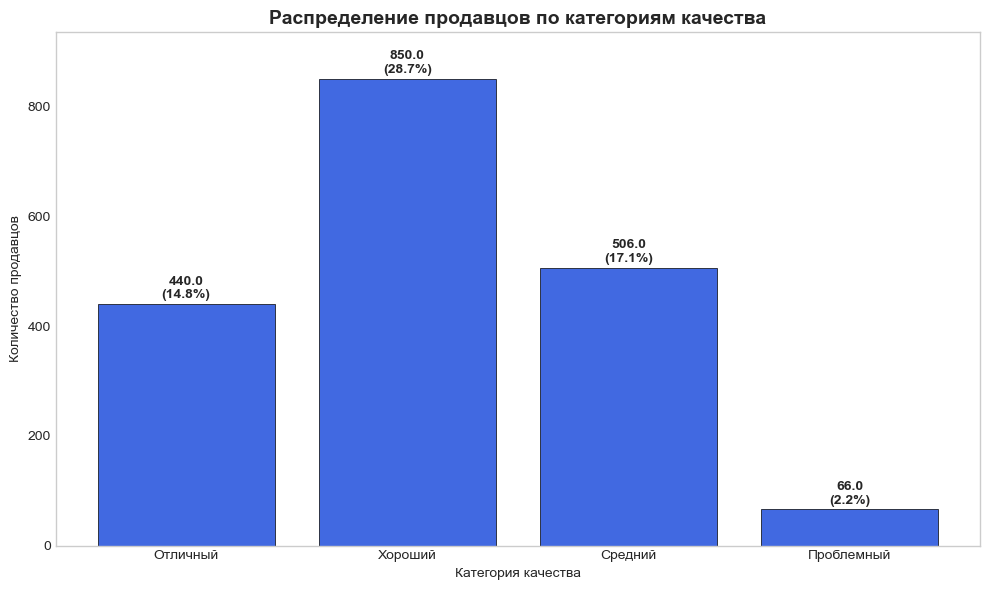

In [81]:
# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')

# Данные из предобработки
category_dist = df_quality['quality_category'].value_counts()

# Порядок категорий (от лучших к худшим)
category_order = ['Отличный', 'Хороший', 'Средний', 'Проблемный', 'Недостаточно данных']
category_dist = category_dist.reindex(category_order)

# Цвета: для Мало заказов - светло-серый, для остальных - Blues_r
colors = []
for cat in category_dist.index:
    if cat == 'Недостаточно данных':
        colors.append('#D3D3D3')  # светло-серый
    else:
        colors.append('royalblue')  # базовый синий

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(category_dist.index, category_dist.values, color=colors, edgecolor='black', linewidth=0.5)

ax.set_title('Распределение продавцов по категориям качества', fontsize=14, fontweight='bold')
ax.set_xlabel('Категория качества')
ax.set_ylabel('Количество продавцов')
ax.set_ylim(0, max(category_dist.values) * 1.1)

# Добавляем подписи на столбцах
for bar, count in zip(bars, category_dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            f'{count}\n({count/len(df_quality)*100:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.grid(False)

plt.tight_layout()
plt.savefig('quality_graph1_categories_bar.jpg', dpi=300, bbox_inches='tight')
plt.savefig('quality_graph1_categories_bar.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [82]:
print("Распределение продавцов по категориям:")
for cat, count in category_dist.items():
    print(f"  {cat}: {count} ({count/len(df_quality)*100:.1f}%)")

Распределение продавцов по категориям:
  Отличный: 440.0 (14.8%)
  Хороший: 850.0 (28.7%)
  Средний: 506.0 (17.1%)
  Проблемный: 66.0 (2.2%)
  Недостаточно данных: nan (nan%)


**Топ-10 штатов по количеству проблемных продавцов**

Нам нужно понять, в каких регионах сосредоточены проблемные продавцы. Горизонтальная гистограмма позволяет быстро сравнить штаты. 

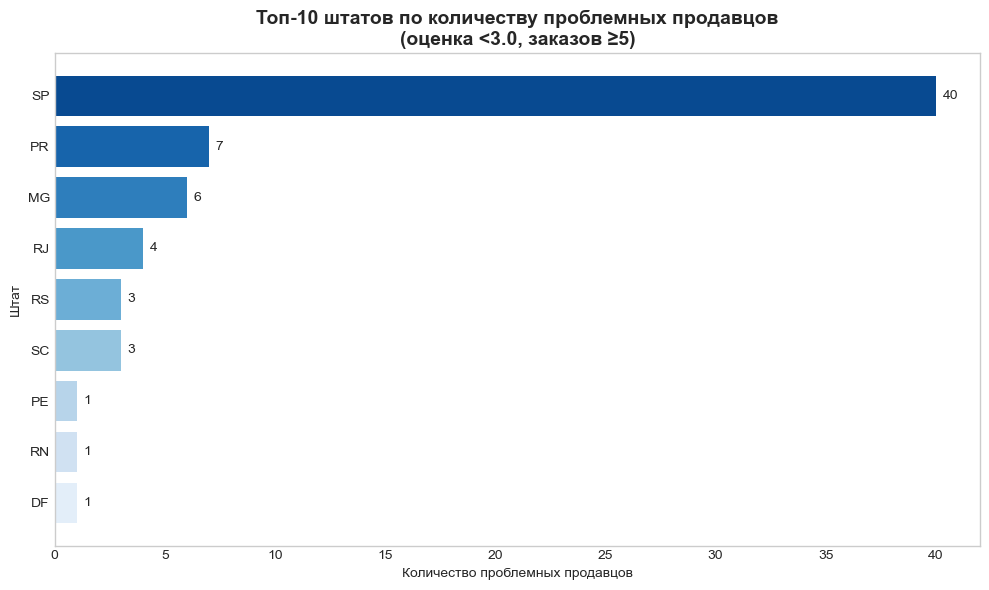

In [83]:
# Данные по проблемным продавцам (с >=5 заказами и оценкой <3.0)
problematic_sellers = df_quality[(df_quality['total_orders'] >= 5) & (df_quality['avg_review_score'] < 3.0)]

# Агрегация по штатам
problematic_by_state = problematic_sellers['seller_state'].value_counts().head(10)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette("Blues_r", len(problematic_by_state))
bars = ax.barh(problematic_by_state.index, problematic_by_state.values, color=colors)
ax.set_title('Топ-10 штатов по количеству проблемных продавцов\n(оценка <3.0, заказов ≥5)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Количество проблемных продавцов')
ax.set_ylabel('Штат')
ax.invert_yaxis()

for bar, count in zip(bars, problematic_by_state.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            str(count), va='center', fontsize=10)

ax.grid(True, axis='x', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
ax.grid(False)
plt.tight_layout()
plt.savefig('quality_graph2_problematic_by_state.jpg', dpi=300, bbox_inches='tight')
plt.savefig('quality_graph2_problematic_by_state.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [84]:
print("Топ-10 штатов по количеству проблемных продавцов:")
print(problematic_by_state)

Топ-10 штатов по количеству проблемных продавцов:
seller_state
SP    40
PR     7
MG     6
RJ     4
RS     3
SC     3
PE     1
RN     1
DF     1
Name: count, dtype: int64


**Распределение средних оценок продавцов (гистограмма)**

Гистограмма показывает, как распределены продавцы по средним оценкам. Это помогает понять, является ли низкая оценка единичным случаем или системной проблемой.

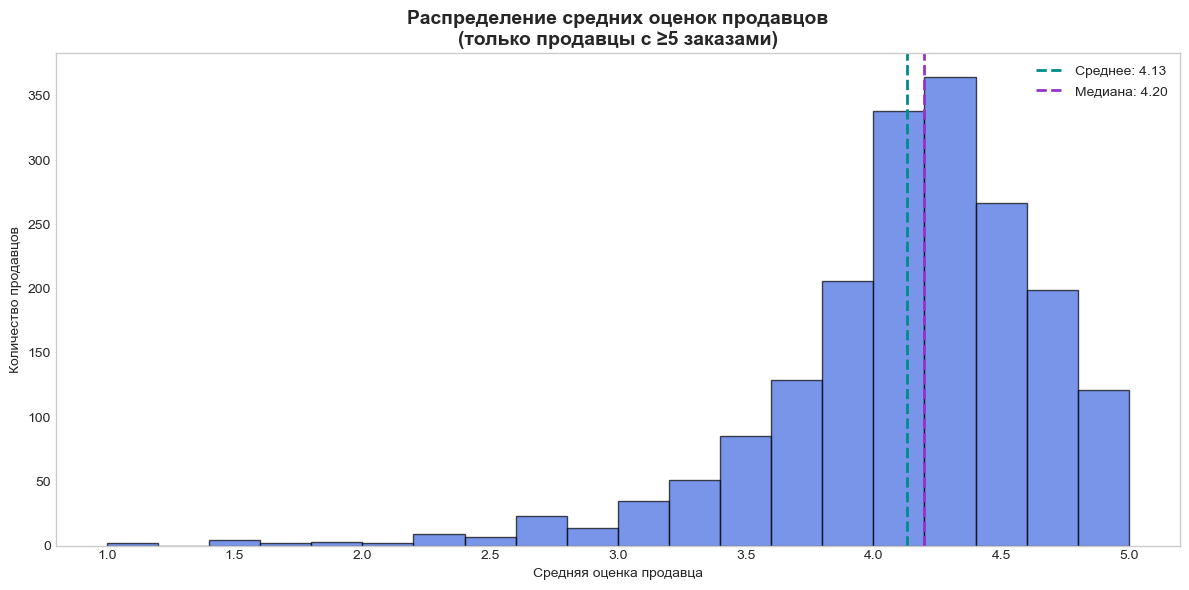

In [85]:
# Фильтруем продавцов с достаточным количеством заказов (≥5)
reliable_sellers = df_quality[df_quality['total_orders'] >= 5]

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(reliable_sellers['avg_review_score'], bins=20, edgecolor='black', 
        color='royalblue', alpha=0.7)
ax.axvline(x=reliable_sellers['avg_review_score'].mean(), color='darkcyan', 
           linestyle='--', linewidth=2, label=f'Среднее: {reliable_sellers["avg_review_score"].mean():.2f}')
ax.axvline(x=reliable_sellers['avg_review_score'].median(), color='darkorchid', 
           linestyle='--', linewidth=2, label=f'Медиана: {reliable_sellers["avg_review_score"].median():.2f}')

ax.set_title('Распределение средних оценок продавцов\n(только продавцы с ≥5 заказами)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Средняя оценка продавца')
ax.set_ylabel('Количество продавцов')
ax.legend()
ax.grid(True, axis='y', linestyle='-', linewidth=0.5, color='gray', alpha=0.3)
ax.grid(False)

plt.tight_layout()
plt.savefig('quality_graph3_score_distribution.jpg', dpi=300, bbox_inches='tight')
plt.savefig('quality_graph3_score_distribution.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [86]:
print(f"Средняя оценка (продавцы с ≥5 заказами): {reliable_sellers['avg_review_score'].mean():.2f}")
print(f"Медианная оценка: {reliable_sellers['avg_review_score'].median():.2f}")
print(f"Стандартное отклонение: {reliable_sellers['avg_review_score'].std():.2f}")

Средняя оценка (продавцы с ≥5 заказами): 4.13
Медианная оценка: 4.20
Стандартное отклонение: 0.53


In [87]:
reliable_sellers.describe()

,total_orders,avg_review_score,negative_reviews,positive_reviews,negative_rate_percent,positive_rate_percent,total_orders_check
count,1862.000000,1862.000000,1862.000000,1862.000000,1862.000000,1862.000000,1862.000000
mean,57.894200,4.133083,8.589151,44.436090,14.028421,78.516165,53.025242
std,147.324737,0.534297,25.146371,110.048692,13.706247,15.887880,133.341549
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,9.000000,3.890000,1.000000,7.000000,4.550000,71.217500,8.000000
50%,18.000000,4.200000,2.000000,14.000000,11.540000,80.000000,16.000000
75%,48.000000,4.460000,7.000000,38.000000,19.080000,88.890000,44.000000
max,1985.000000,5.000000,397.000000,1439.000000,100.000000,100.000000,1782.000000


**Корреляция между количеством заказов и средней оценкой**

Чтобы понять, есть ли связь между объемом продаж продавца и его оценкой, используем корреляционный анализ. Для наглядности добавим: ящик с усами (boxplot) для сравнения оценок в группах продавцов по количеству заказов, а также рассчитаем коэффициент корреляции.

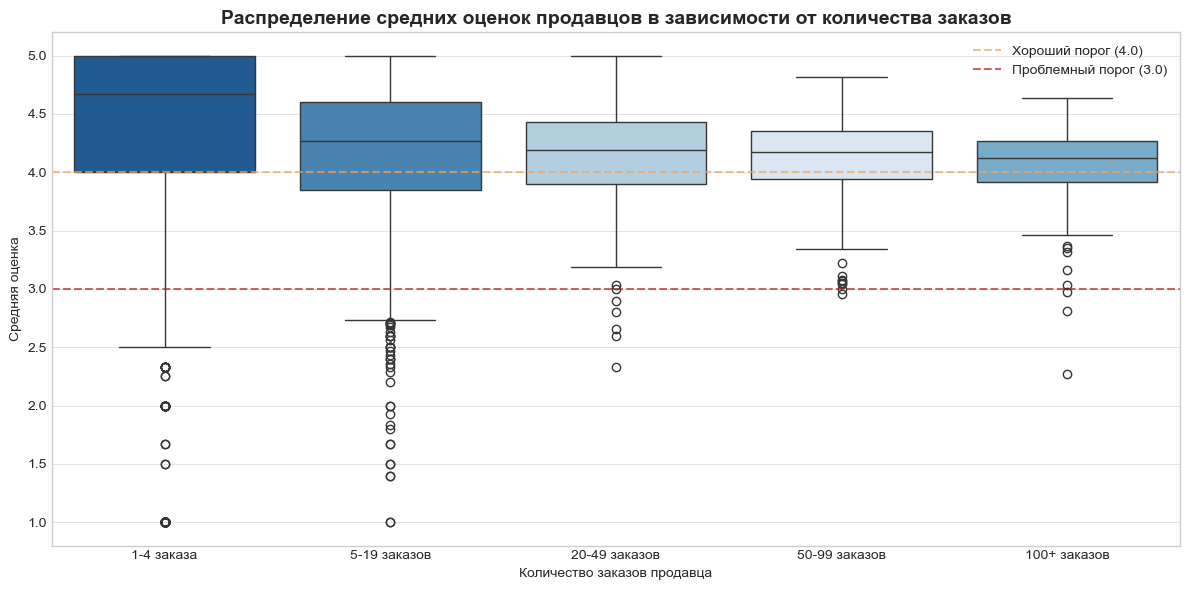

In [88]:
# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')

# Создаем группы продавцов по количеству заказов
def orders_group(orders):
    if orders < 5:
        return '1-4 заказа'
    elif orders < 20:
        return '5-19 заказов'
    elif orders < 50:
        return '20-49 заказов'
    elif orders < 100:
        return '50-99 заказов'
    else:
        return '100+ заказов'

df_quality['orders_group'] = df_quality['total_orders'].apply(orders_group)

# Порядок групп
group_order = ['1-4 заказа', '5-19 заказов', '20-49 заказов', '50-99 заказов', '100+ заказов']

# Визуализация: boxplot (исправленный)
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df_quality, x='orders_group', y='avg_review_score', 
            order=group_order, hue='orders_group', palette='Blues_r', legend=False, ax=ax)

ax.set_title('Распределение средних оценок продавцов в зависимости от количества заказов', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Количество заказов продавца')
ax.set_ylabel('Средняя оценка')
ax.axhline(y=4.0, color='sandybrown', linestyle='--', alpha=0.7, label='Хороший порог (4.0)')
ax.axhline(y=3.0, color='firebrick', linestyle='--', alpha=0.7, label='Проблемный порог (3.0)')
ax.legend()
ax.grid(True, axis='y', linestyle='-', linewidth=0.5, color='gray', alpha=0.3)

plt.tight_layout()
plt.savefig('quality_graph4_orders_vs_score_boxplot.jpg', dpi=300, bbox_inches='tight')
plt.savefig('quality_graph4_orders_vs_score_boxplot.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [89]:
# Расчет корреляции
# Корреляция Пирсона
pearson_corr, pearson_p = stats.pearsonr(df_quality['total_orders'], df_quality['avg_review_score'])
print(f"Корреляция Пирсона: {pearson_corr:.3f} (p-value: {pearson_p:.5f})")

# Корреляция Спирмена (ранговая, лучше для ненормального распределения)
spearman_corr, spearman_p = stats.spearmanr(df_quality['total_orders'], df_quality['avg_review_score'])
print(f"Корреляция Спирмена: {spearman_corr:.3f} (p-value: {spearman_p:.5f})")

print("\nИнтерпретация:")
if abs(spearman_corr) < 0.2:
    print("  Связь отсутствует или очень слабая")
elif abs(spearman_corr) < 0.4:
    print("  Связь слабая")
elif abs(spearman_corr) < 0.6:
    print("  Связь умеренная")
elif abs(spearman_corr) < 0.8:
    print("  Связь сильная")
else:
    print("  Связь очень сильная")

print(f"  Направление: {'положительная' if spearman_corr > 0 else 'отрицательная'}")

Корреляция Пирсона: -0.027 (p-value: 0.14318)
Корреляция Спирмена: -0.253 (p-value: 0.00000)

Интерпретация:
  Связь слабая
  Направление: отрицательная


In [90]:
# Статистика по группам
group_stats = df_quality.groupby('orders_group').agg({
    'avg_review_score': ['mean', 'median', 'std', 'count'],
    'total_orders': 'sum'
}).round(3)

group_stats.columns = ['средняя_оценка', 'медиана_оценки', 'std_оценки', 'количество_продавцов', 'всего_заказов']
group_stats = group_stats.reindex(group_order)

print(group_stats.to_string())

               средняя_оценка  медиана_оценки  std_оценки  количество_продавцов  всего_заказов
orders_group                                                                                  
1-4 заказа              4.181           4.670       1.107                  1103           2212
5-19 заказов            4.148           4.270       0.649                   984           9792
20-49 заказов           4.142           4.195       0.400                   420          13157
50-99 заказов           4.123           4.170       0.354                   223          16019
100+ заказов            4.063           4.120       0.303                   235          68831


**Доля негативных отзывов по штатам**

Тепловая карта (или горизонтальная гистограмма) показывает, в каких регионах клиенты чаще оставляют негативные отзывы. Это помогает отделу качества сфокусироваться на проблемных регионах. 

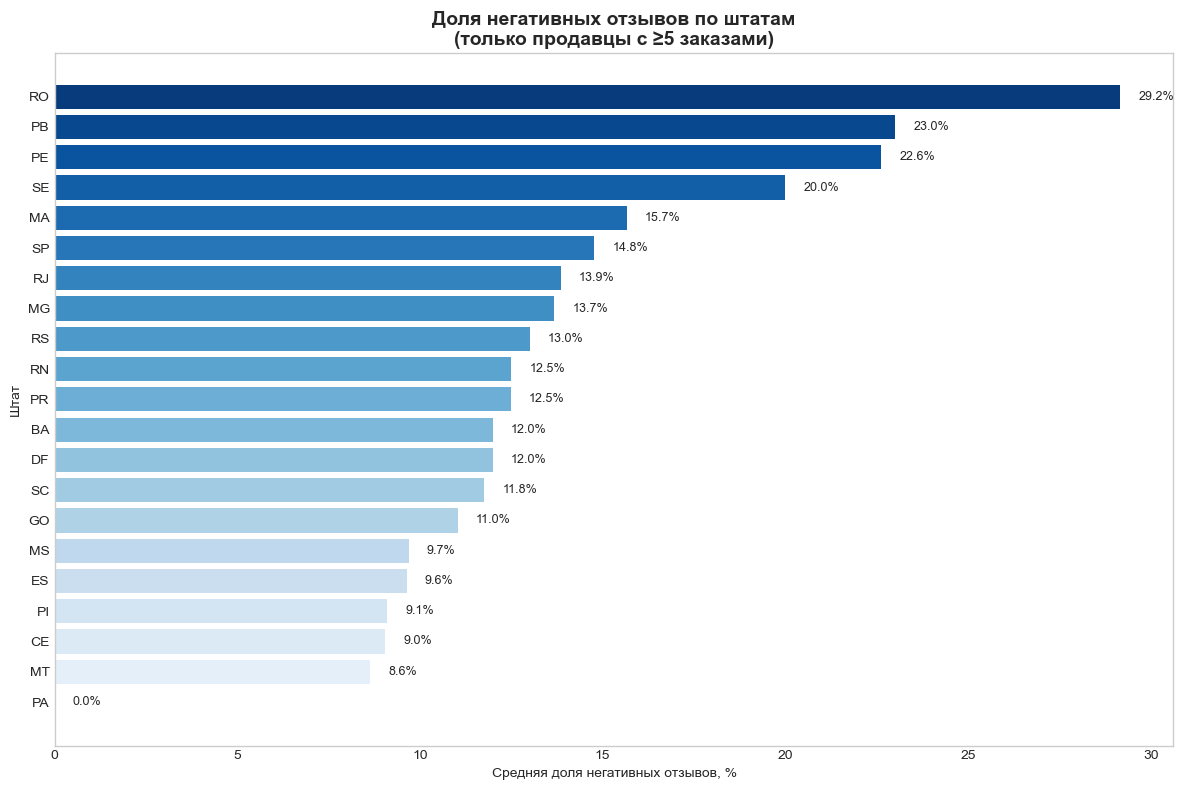

In [91]:
# Агрегация по штатам (только продавцы с ≥5 заказами)
state_quality = df_quality[df_quality['total_orders'] >= 5].groupby('seller_state').agg({
    'negative_rate_percent': 'mean',
    'total_orders': 'sum',
    'seller_id': 'count'
}).reset_index()
state_quality.columns = ['seller_state', 'avg_negative_rate', 'total_orders', 'sellers_count']
state_quality = state_quality.sort_values('avg_negative_rate', ascending=False)

# Визуализация
fig, ax = plt.subplots(figsize=(12, 8))

# Цвета от lightblue до darkcyan
colors = sns.color_palette("Blues_r", len(state_quality))
bars = ax.barh(state_quality['seller_state'], state_quality['avg_negative_rate'], color=colors)
ax.set_title('Доля негативных отзывов по штатам\n(только продавцы с ≥5 заказами)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Средняя доля негативных отзывов, %')
ax.set_ylabel('Штат')
ax.invert_yaxis()

for bar, rate in zip(bars, state_quality['avg_negative_rate']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{rate:.1f}%', va='center', fontsize=9)

# Увеличиваем правую границу графика на 10%
ax.set_xlim(0, state_quality['avg_negative_rate'].max() * 1.05)

ax.grid(False)
plt.tight_layout()
plt.savefig('quality_graph5_negative_by_state.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [92]:
print("Топ-5 штатов по доле негативных отзывов:")
print(state_quality.head(5)[['seller_state', 'avg_negative_rate', 'total_orders', 'sellers_count']].to_string(index=False))
print("\nТоп-5 штатов с наименьшей долей негативных отзывов:")
print(state_quality.tail(5)[['seller_state', 'avg_negative_rate', 'total_orders', 'sellers_count']].to_string(index=False))

Топ-5 штатов по доле негативных отзывов:
seller_state  avg_negative_rate  total_orders  sellers_count
          RO          29.165000            14              2
          PB          23.013333            32              3
          PE          22.616000           435              5
          SE          20.000000            10              2
          MA          15.660000           396              1

Топ-5 штатов с наименьшей долей негативных отзывов:
seller_state  avg_negative_rate  total_orders  sellers_count
          ES           9.634167           340             12
          PI           9.090000            11              1
          CE           9.046000            78              5
          MT           8.633333           142              3
          PA           0.000000             8              1


**Топ-10 проблемных продавцов (с наибольшим количеством заказов среди проблемных)**

Чтобы отдел качества мог адресно работать с самыми проблемными продавцами, которые при этом имеют много заказов (то есть наносят наибольший урон репутации).

In [93]:
# Выделяем проблемных продавцов с >=10 заказами и оценкой <3.0
critical_sellers = df_quality[(df_quality['total_orders'] >= 10) & (df_quality['avg_review_score'] < 3.0)].copy()
critical_sellers = critical_sellers.sort_values('total_orders', ascending=False).head(10)

print("Топ-10 проблемных продавцов с высоким объемом заказов:")
print(critical_sellers[['seller_id', 'seller_state', 'total_orders', 'avg_review_score', 'negative_rate_percent']].to_string(index=False))

# Сохраняем в Excel файл
output_file = 'critical_sellers_top10.xlsx'

# Подготавливаем DataFrame для сохранения с русскими названиями столбцов
df_to_save = critical_sellers[['seller_id', 'seller_state', 'total_orders', 'avg_review_score', 'negative_rate_percent']].copy()
df_to_save.columns = ['ID продавца', 'Штат', 'Количество заказов', 'Средняя оценка', 'Доля негатива (%)']

# Сохраняем в Excel
df_to_save.to_excel(output_file, index=False, sheet_name='Проблемные продавцы')

print(f"\nТаблица сохранена в файл: {output_file}")
print(f"ист: Проблемные продавцы")

Топ-10 проблемных продавцов с высоким объемом заказов:
                       seller_id seller_state  total_orders  avg_review_score  negative_rate_percent
2eb70248d66e0e3ef83659f71b244378           SP           195              2.81                  47.69
1ca7077d890b907f89be8c954a02686a           SP           126              2.27                  63.49
a49928bcdf77c55c6d6e05e09a9b4ca5           SP           104              2.97                  43.27
972d0f9cf61b499a4812cf0bfa3ad3c4           SC            84              2.96                  44.05
2709af9587499e95e803a6498a5a56e9           SP            45              2.60                  57.78
bb135baca94c82fcb731335ad5b04a03           SP            38              2.66                  52.63
66fd84ee7528c0c0de85d0f44a73d5ab           RS            21              2.90                  38.10
5bc55dbe2f12b6af6d83ed46023e0dc8           MG            21              2.33                  57.14
e250d617a0ad591ba9bd663e584a895d    

**Выгружаем готовые датасеты для дашборда**

In [94]:
# Для логистики (df_logistics)
df_logistics_dashboard = df_logistics[['order_date', 'customer_state', 'delay_rate_percent', 'avg_review_score']]
df_logistics_dashboard.to_csv('dashboard_logistics.csv', index=False, encoding='utf-8-sig')

# Для продаж ( df_sales)
df_sales_dashboard = df_sales[['order_date', 'customer_state', 'total_revenue', 'total_orders']]
df_sales_dashboard.to_csv('dashboard_sales.csv', index=False, encoding='utf-8-sig')

# Для качества ( df_quality)
df_quality_dashboard = df_quality[['seller_state', 'quality_category', 'negative_rate_percent', 'total_orders']]
df_quality_dashboard.to_csv('dashboard_quality.csv', index=False, encoding='utf-8-sig')